# EEG Classification Model for Epileptic Seizure Detection

## Project Overview
This project builds a classification model to analyze and classify EEG (Electroencephalogram) data from the Bonn EEG Dataset. EEG data is widely used in neuroscience and medical fields, particularly for the diagnosis of epilepsy.

### Dataset Description - Bonn EEG Dataset
The dataset contains five sets (A-E) with 100 single-channel EEG segments each:
- **Set Z (Folder Z)**: Eyes open, healthy volunteers
- **Set O (Folder O)**: Eyes closed, healthy volunteers  
- **Set N (Folder N)**: Seizure-free intervals, hippocampal formation
- **Set F (Folder F)**: Seizure-free intervals, epileptogenic zone
- **Set S (Folder S)**: Seizure activity

Each recording is 23.6 seconds long with 4097 data points (173.61 Hz sampling rate).

---


## 1. Import Libraries and Setup


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Signal processing
from scipy import signal
from scipy.stats import skew, kurtosis, entropy
from scipy.fft import fft, fftfreq

# Machine Learning (for metrics and data splitting)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, confusion_matrix, classification_report,
                            roc_curve, auc, roc_auc_score)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, LSTM, Dense, 
                                     Dropout, Flatten, BatchNormalization,
                                     Bidirectional, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


All libraries imported successfully!
TensorFlow version: 2.20.0


---
## 2. Data Loading and Exploration


In [2]:
# Define data path
DATA_PATH = "Bonn Dataset"

# Define class labels and their descriptions
CLASS_INFO = {
    'Z': {'label': 0, 'description': 'Healthy - Eyes Open', 'category': 'Normal'},
    'O': {'label': 1, 'description': 'Healthy - Eyes Closed', 'category': 'Normal'},
    'N': {'label': 2, 'description': 'Epileptic - Hippocampal', 'category': 'Interictal'},
    'F': {'label': 3, 'description': 'Epileptic - Epileptogenic Zone', 'category': 'Interictal'},
    'S': {'label': 4, 'description': 'Seizure Activity', 'category': 'Ictal'}
}

# Sampling frequency
SAMPLING_FREQ = 173.61  # Hz
DURATION = 23.6  # seconds

def load_eeg_data(data_path):
    """
    Load all EEG data from the Bonn dataset.
    
    Returns:
        data: numpy array of shape (n_samples, n_timepoints)
        labels: numpy array of class labels
        class_names: list of class folder names
    """
    data = []
    labels = []
    class_names = []
    file_names = []
    
    for folder in ['Z', 'O', 'N', 'F', 'S']:
        folder_path = os.path.join(data_path, folder)
        
        # Get all txt files
        files = glob.glob(os.path.join(folder_path, '*.txt')) + \
                glob.glob(os.path.join(folder_path, '*.TXT'))
        
        print(f"Loading {len(files)} files from folder {folder}...")
        
        for file_path in sorted(files):
            try:
                # Read the signal values
                signal_data = np.loadtxt(file_path)
                data.append(signal_data)
                labels.append(CLASS_INFO[folder]['label'])
                class_names.append(folder)
                file_names.append(os.path.basename(file_path))
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return np.array(data), np.array(labels), class_names, file_names

# Load the data
print("Loading EEG data from Bonn Dataset...\n")
raw_data, labels, class_names, file_names = load_eeg_data(DATA_PATH)

print(f"\n✓ Data loaded successfully!")
print(f"  - Total samples: {raw_data.shape[0]}")
print(f"  - Time points per sample: {raw_data.shape[1]}")
print(f"  - Sampling frequency: {SAMPLING_FREQ} Hz")
print(f"  - Duration per recording: {DURATION} seconds")


Loading EEG data from Bonn Dataset...

Loading 100 files from folder Z...
Loading 100 files from folder O...
Loading 100 files from folder N...
Loading 100 files from folder F...
Loading 100 files from folder S...

✓ Data loaded successfully!
  - Total samples: 500
  - Time points per sample: 4097
  - Sampling frequency: 173.61 Hz
  - Duration per recording: 23.6 seconds



=== Class Distribution ===
class_folder                    description   category  count
           F Epileptic - Epileptogenic Zone Interictal    100
           N        Epileptic - Hippocampal Interictal    100
           O          Healthy - Eyes Closed     Normal    100
           S               Seizure Activity      Ictal    100
           Z            Healthy - Eyes Open     Normal    100


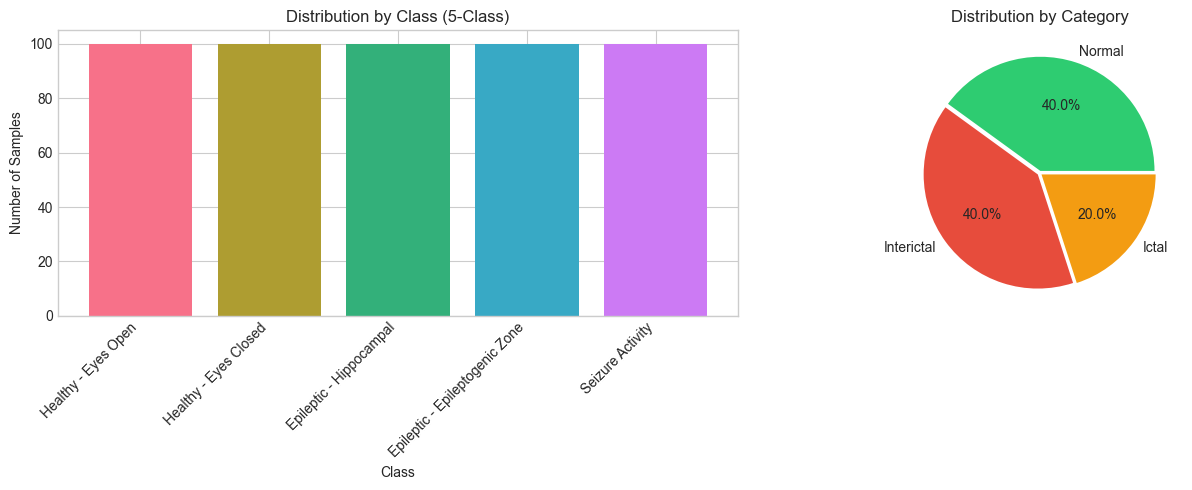

In [3]:
# Create a DataFrame for easier analysis
df_info = pd.DataFrame({
    'file_name': file_names,
    'class_folder': class_names,
    'label': labels,
    'description': [CLASS_INFO[c]['description'] for c in class_names],
    'category': [CLASS_INFO[c]['category'] for c in class_names]
})

# Display class distribution
print("\n=== Class Distribution ===")
class_dist = df_info.groupby(['class_folder', 'description', 'category']).size().reset_index(name='count')
print(class_dist.to_string(index=False))

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By class
colors = sns.color_palette("husl", 5)
class_counts = df_info['description'].value_counts()
axes[0].bar(range(len(class_counts)), class_counts.values, color=colors)
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(class_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Distribution by Class (5-Class)')

# By category
category_counts = df_info['category'].value_counts()
colors_cat = ['#2ecc71', '#e74c3c', '#f39c12']
axes[1].pie(category_counts.values, labels=category_counts.index, 
            autopct='%1.1f%%', colors=colors_cat, explode=[0.02]*len(category_counts))
axes[1].set_title('Distribution by Category')

plt.tight_layout()
plt.show()


---
## 3. Data Visualization and Exploration


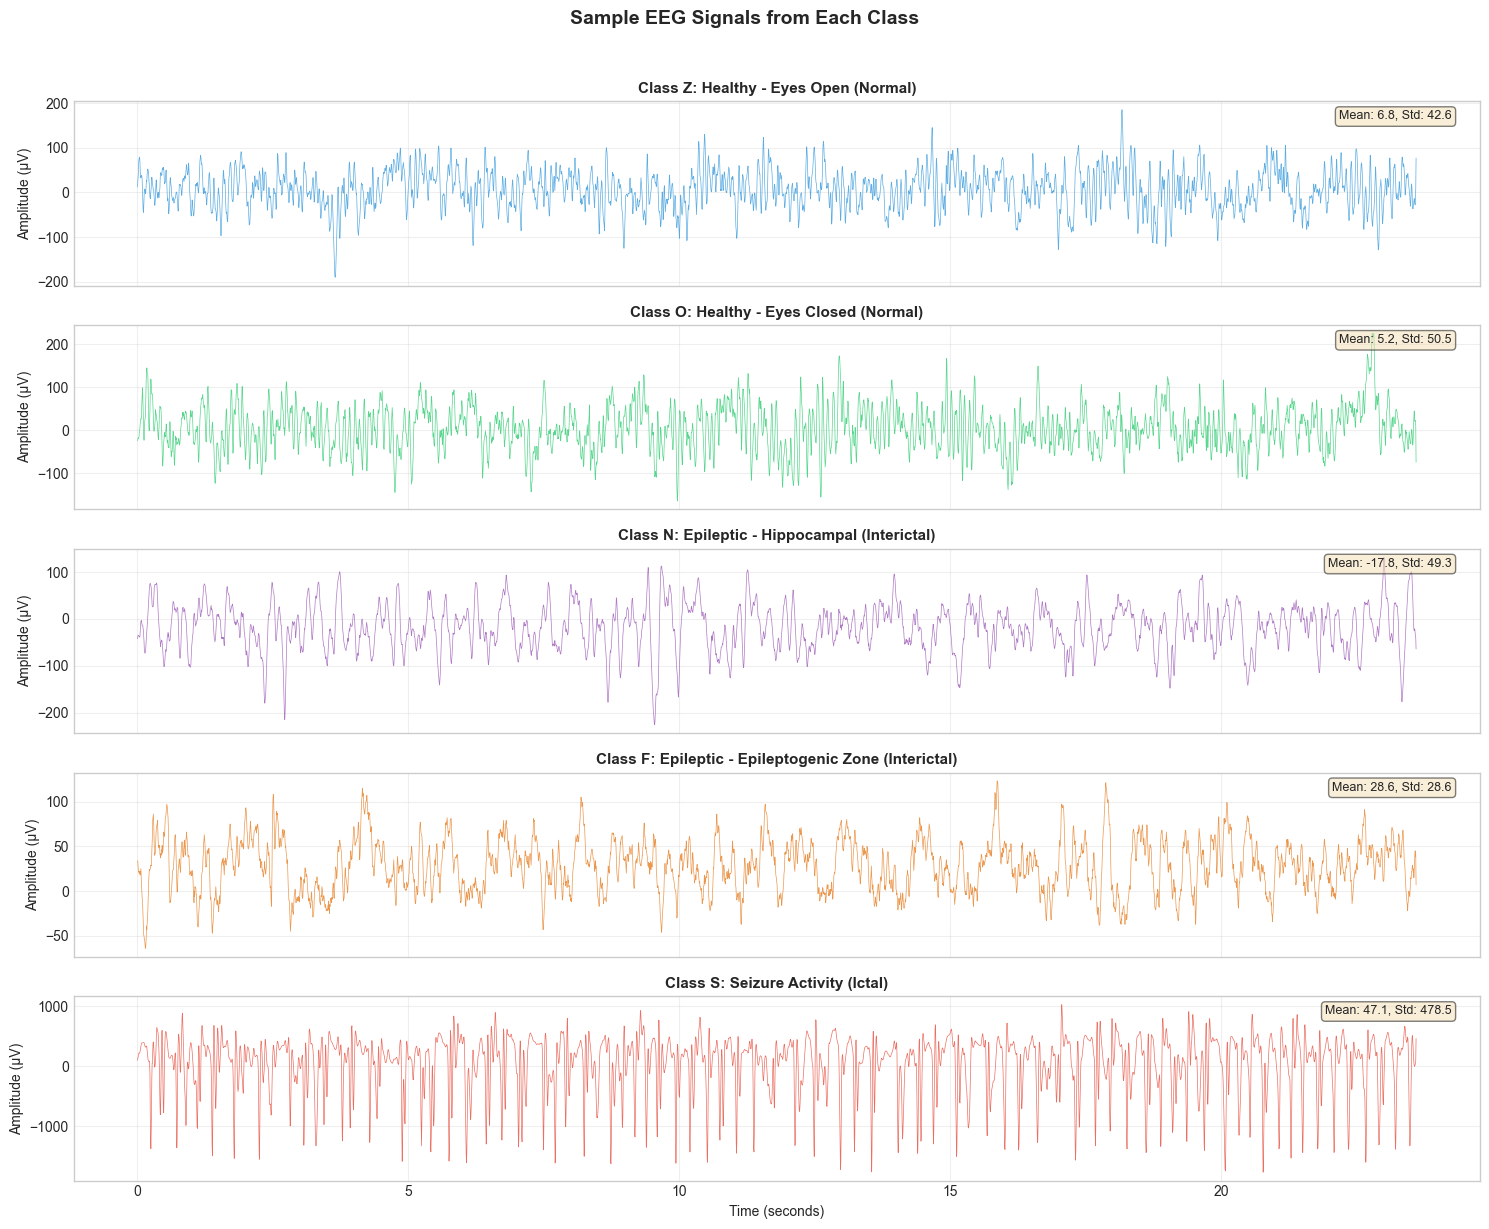

In [4]:
# Create time array
time = np.arange(raw_data.shape[1]) / SAMPLING_FREQ

# Plot sample EEG signals from each class
fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

for idx, (folder, info) in enumerate(CLASS_INFO.items()):
    # Get first sample from each class
    sample_idx = np.where(labels == info['label'])[0][0]
    signal_sample = raw_data[sample_idx]
    
    axes[idx].plot(time, signal_sample, color=colors[idx], linewidth=0.5, alpha=0.8)
    axes[idx].set_ylabel('Amplitude (μV)')
    axes[idx].set_title(f"Class {folder}: {info['description']} ({info['category']})", 
                        fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    
    # Add statistics annotation
    stats_text = f"Mean: {signal_sample.mean():.1f}, Std: {signal_sample.std():.1f}"
    axes[idx].annotate(stats_text, xy=(0.98, 0.95), xycoords='axes fraction',
                       ha='right', va='top', fontsize=9,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Sample EEG Signals from Each Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


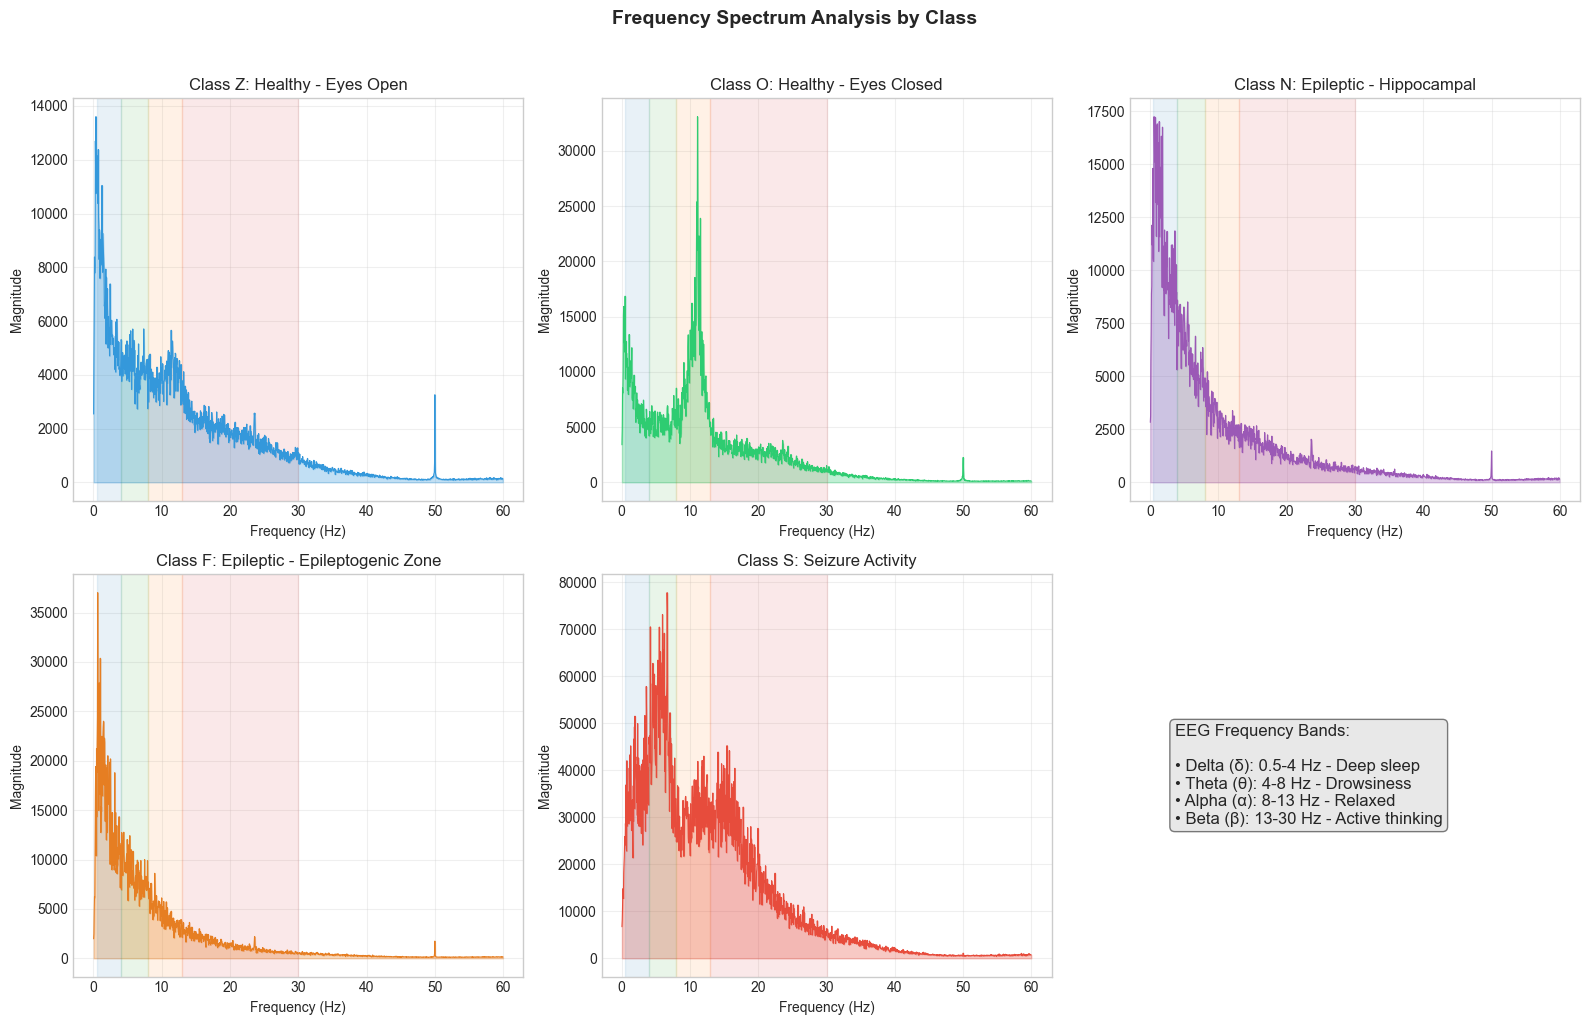

In [5]:
# Compute and visualize frequency spectrum for each class
def compute_fft(signal_data, sampling_freq):
    """Compute the FFT and return frequencies and magnitudes."""
    n = len(signal_data)
    fft_vals = fft(signal_data)
    freqs = fftfreq(n, 1/sampling_freq)
    
    # Take only positive frequencies
    positive_mask = freqs > 0
    freqs = freqs[positive_mask]
    magnitude = np.abs(fft_vals[positive_mask])
    
    return freqs, magnitude

# Plot frequency analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (folder, info) in enumerate(CLASS_INFO.items()):
    # Get samples for this class
    class_mask = labels == info['label']
    class_data = raw_data[class_mask]
    
    # Compute average power spectrum
    avg_magnitude = np.zeros(len(class_data[0])//2)
    for sample in class_data[:20]:  # Use first 20 samples
        freqs, magnitude = compute_fft(sample, SAMPLING_FREQ)
        avg_magnitude[:len(magnitude)] += magnitude
    avg_magnitude /= 20
    
    # Plot up to 60 Hz
    freq_mask = freqs <= 60
    axes[idx].plot(freqs[freq_mask], avg_magnitude[:len(freqs)][freq_mask], 
                   color=colors[idx], linewidth=0.8)
    axes[idx].fill_between(freqs[freq_mask], avg_magnitude[:len(freqs)][freq_mask], 
                           alpha=0.3, color=colors[idx])
    axes[idx].set_xlabel('Frequency (Hz)')
    axes[idx].set_ylabel('Magnitude')
    axes[idx].set_title(f"Class {folder}: {info['description']}")
    axes[idx].grid(True, alpha=0.3)
    
    # Add frequency band annotations
    for band, (low, high, c) in {'δ': (0.5, 4, '#1f77b4'), 'θ': (4, 8, '#2ca02c'), 
                                  'α': (8, 13, '#ff7f0e'), 'β': (13, 30, '#d62728')}.items():
        axes[idx].axvspan(low, high, alpha=0.1, color=c)

# Legend for frequency bands
axes[5].axis('off')
bands_info = "EEG Frequency Bands:\n\n• Delta (δ): 0.5-4 Hz - Deep sleep\n• Theta (θ): 4-8 Hz - Drowsiness\n• Alpha (α): 8-13 Hz - Relaxed\n• Beta (β): 13-30 Hz - Active thinking"
axes[5].text(0.1, 0.5, bands_info, transform=axes[5].transAxes, fontsize=12,
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.suptitle('Frequency Spectrum Analysis by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# Statistical summary of raw data
stats_list = []

for folder, info in CLASS_INFO.items():
    class_mask = labels == info['label']
    class_data = raw_data[class_mask]
    
    stats_list.append({
        'Class': folder,
        'Description': info['description'],
        'Mean': class_data.mean(),
        'Std': class_data.std(),
        'Min': class_data.min(),
        'Max': class_data.max(),
        'Range': class_data.max() - class_data.min(),
        'Skewness': np.mean([skew(s) for s in class_data]),
        'Kurtosis': np.mean([kurtosis(s) for s in class_data])
    })

stats_df = pd.DataFrame(stats_list)
print("\n=== Statistical Summary by Class ===")
print(stats_df.to_string(index=False))



=== Statistical Summary by Class ===
Class                    Description       Mean        Std     Min    Max  Range  Skewness  Kurtosis
    Z            Healthy - Eyes Open  -6.260845  48.338960  -288.0  294.0  582.0 -0.021191  0.226986
    O          Healthy - Eyes Closed -12.513293  70.682038  -424.0  360.0  784.0  0.057690  0.218179
    N        Epileptic - Hippocampal  -8.880034  59.385825  -412.0  623.0 1035.0 -0.151338  0.645681
    F Epileptic - Epileptogenic Zone  -6.203012  90.345458 -1147.0 2047.0 3194.0  0.077590  1.322125
    S               Seizure Activity  -4.748914 341.159281 -1885.0 2047.0 3932.0 -0.059880  0.428355


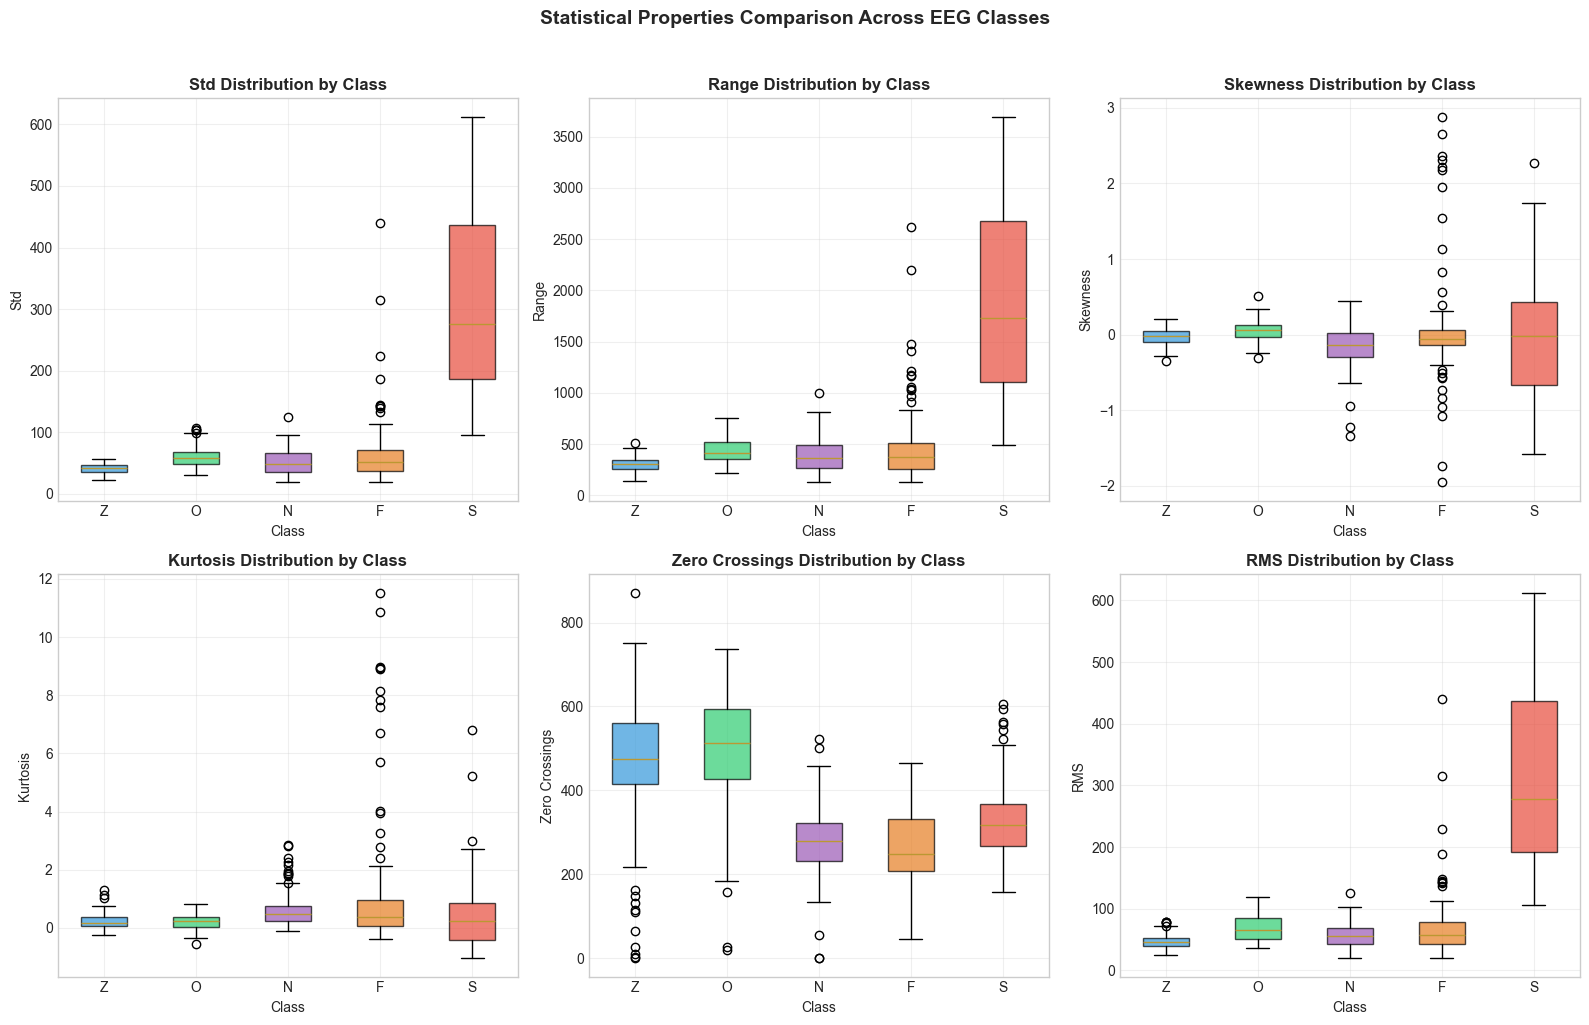

In [7]:
# Box plot comparison of signal statistics across classes
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Calculate statistics for each sample
sample_stats = []
for i, signal_sample in enumerate(raw_data):
    sample_stats.append({
        'Class': class_names[i],
        'Category': CLASS_INFO[class_names[i]]['category'],
        'Std': np.std(signal_sample),
        'Range': np.max(signal_sample) - np.min(signal_sample),
        'Skewness': skew(signal_sample),
        'Kurtosis': kurtosis(signal_sample),
        'Zero Crossings': np.sum(np.diff(np.sign(signal_sample)) != 0),
        'RMS': np.sqrt(np.mean(signal_sample**2))
    })

stats_sample_df = pd.DataFrame(sample_stats)

# Create box plots for different statistics
stat_names = ['Std', 'Range', 'Skewness', 'Kurtosis', 'Zero Crossings', 'RMS']
class_order = ['Z', 'O', 'N', 'F', 'S']

for idx, stat in enumerate(stat_names):
    ax = axes[idx // 3, idx % 3]
    box_colors = {'Z': '#3498db', 'O': '#2ecc71', 'N': '#9b59b6', 'F': '#e67e22', 'S': '#e74c3c'}
    
    bp = ax.boxplot([stats_sample_df[stats_sample_df['Class'] == c][stat].values for c in class_order],
                    labels=class_order, patch_artist=True)
    
    for patch, c in zip(bp['boxes'], class_order):
        patch.set_facecolor(box_colors[c])
        patch.set_alpha(0.7)
    
    ax.set_title(f'{stat} Distribution by Class', fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel(stat)
    ax.grid(True, alpha=0.3)

plt.suptitle('Statistical Properties Comparison Across EEG Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


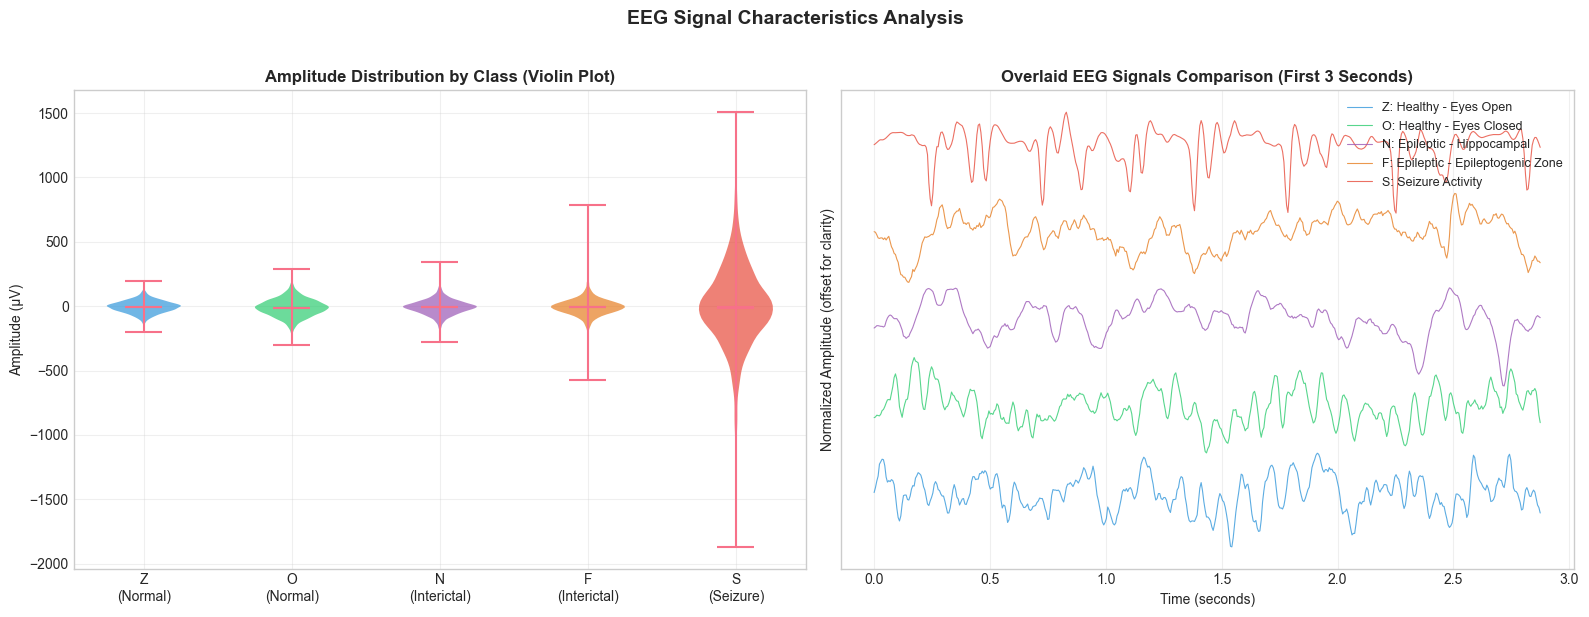


📊 Key Observations:
   • Seizure signals (S) show much higher amplitude variability
   • Normal signals (Z, O) have relatively lower amplitude ranges
   • Interictal signals (N, F) show intermediate characteristics


In [8]:
# Violin plot and Signal Overlay Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Violin plot showing amplitude distribution by class
ax1 = axes[0]
# Sample amplitude values from each class for violin plot
amplitude_data = []
class_labels_violin = []
for folder in ['Z', 'O', 'N', 'F', 'S']:
    class_mask = np.array(class_names) == folder
    class_signals = raw_data[class_mask]
    # Sample 1000 points from each class
    sampled_amplitudes = class_signals.flatten()[::100][:5000]
    amplitude_data.extend(sampled_amplitudes)
    class_labels_violin.extend([folder] * len(sampled_amplitudes))

violin_df = pd.DataFrame({'Class': class_labels_violin, 'Amplitude': amplitude_data})

parts = ax1.violinplot([violin_df[violin_df['Class'] == c]['Amplitude'].values for c in ['Z', 'O', 'N', 'F', 'S']],
                       positions=[1, 2, 3, 4, 5], showmeans=True, showmedians=True)

violin_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']
for pc, color in zip(parts['bodies'], violin_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['Z\n(Normal)', 'O\n(Normal)', 'N\n(Interictal)', 'F\n(Interictal)', 'S\n(Seizure)'])
ax1.set_ylabel('Amplitude (μV)')
ax1.set_title('Amplitude Distribution by Class (Violin Plot)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# 2. Overlaid signals from different classes (short segment)
ax2 = axes[1]
time_segment = time[:500]  # First ~3 seconds

for idx, (folder, info) in enumerate(CLASS_INFO.items()):
    sample_idx = np.where(labels == info['label'])[0][0]
    signal_segment = raw_data[sample_idx][:500]
    # Normalize for comparison
    signal_normalized = (signal_segment - signal_segment.mean()) / signal_segment.std()
    ax2.plot(time_segment, signal_normalized + idx * 5, color=colors[idx], 
             linewidth=0.8, label=f"{folder}: {info['description']}", alpha=0.8)

ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Normalized Amplitude (offset for clarity)')
ax2.set_title('Overlaid EEG Signals Comparison (First 3 Seconds)', fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_yticks([])

plt.suptitle('EEG Signal Characteristics Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Observations:")
print("   • Seizure signals (S) show much higher amplitude variability")
print("   • Normal signals (Z, O) have relatively lower amplitude ranges")
print("   • Interictal signals (N, F) show intermediate characteristics")


---
## 4. Data Preprocessing


Preprocessing EEG data...
✓ Preprocessing complete!


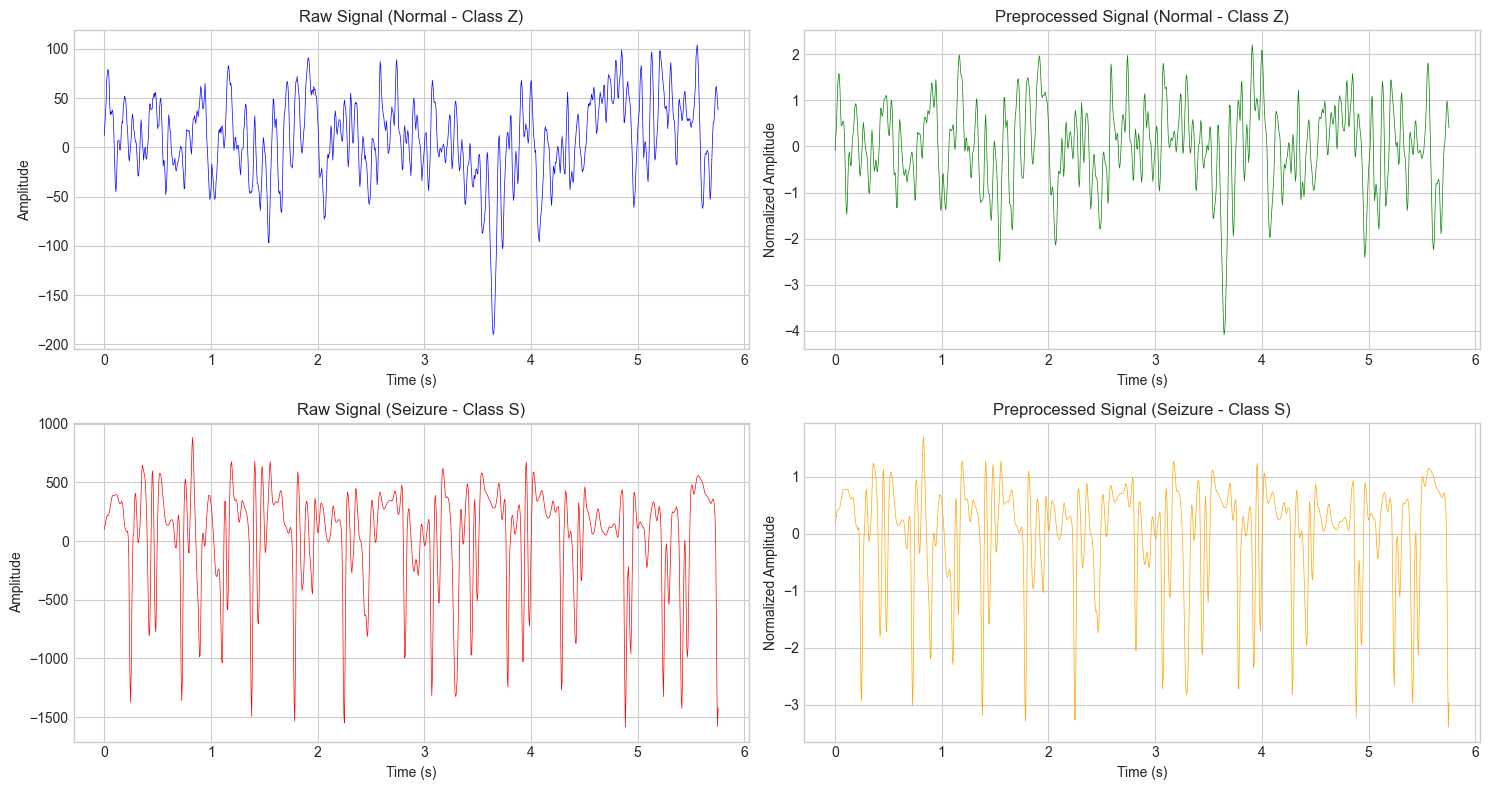

In [9]:
def bandpass_filter(data, lowcut=0.5, highcut=50, fs=173.61, order=4):
    """
    Apply a Butterworth bandpass filter to remove noise.
    
    Parameters:
        data: input signal
        lowcut: lower cutoff frequency (Hz)
        highcut: upper cutoff frequency (Hz)
        fs: sampling frequency
        order: filter order
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    filtered_data = signal.filtfilt(b, a, data)
    return filtered_data

def normalize_signal(data):
    """Z-score normalization."""
    return (data - np.mean(data)) / np.std(data)

def preprocess_eeg(raw_data):
    """
    Preprocess EEG data:
    1. Apply bandpass filter (0.5-50 Hz)
    2. Normalize signals
    """
    preprocessed = np.zeros_like(raw_data)
    
    for i in range(len(raw_data)):
        # Bandpass filter
        filtered = bandpass_filter(raw_data[i])
        # Normalize
        preprocessed[i] = normalize_signal(filtered)
    
    return preprocessed

print("Preprocessing EEG data...")
preprocessed_data = preprocess_eeg(raw_data)
print("✓ Preprocessing complete!")

# Visualize before and after preprocessing
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

sample_idx = 0
# Raw vs Preprocessed (Normal class)
axes[0, 0].plot(time[:1000], raw_data[sample_idx][:1000], 'b-', linewidth=0.5)
axes[0, 0].set_title('Raw Signal (Normal - Class Z)')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Amplitude')

axes[0, 1].plot(time[:1000], preprocessed_data[sample_idx][:1000], 'g-', linewidth=0.5)
axes[0, 1].set_title('Preprocessed Signal (Normal - Class Z)')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Normalized Amplitude')

# Seizure class
seizure_idx = np.where(labels == 4)[0][0]
axes[1, 0].plot(time[:1000], raw_data[seizure_idx][:1000], 'r-', linewidth=0.5)
axes[1, 0].set_title('Raw Signal (Seizure - Class S)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_ylabel('Amplitude')

axes[1, 1].plot(time[:1000], preprocessed_data[seizure_idx][:1000], 'orange', linewidth=0.5)
axes[1, 1].set_title('Preprocessed Signal (Seizure - Class S)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Normalized Amplitude')

plt.tight_layout()
plt.show()


---
## 5. Feature Extraction

### 5.1 Time-Domain, Frequency-Domain, and Hjorth Features


In [10]:
def extract_time_domain_features(signal_data):
    """
    Extract time-domain features from EEG signal.
    """
    features = {
        'mean': np.mean(signal_data),
        'std': np.std(signal_data),
        'var': np.var(signal_data),
        'max': np.max(signal_data),
        'min': np.min(signal_data),
        'peak_to_peak': np.max(signal_data) - np.min(signal_data),
        'skewness': skew(signal_data),
        'kurtosis': kurtosis(signal_data),
        'rms': np.sqrt(np.mean(signal_data**2)),
        'zero_crossings': np.sum(np.diff(np.sign(signal_data)) != 0),
        'mean_abs_diff': np.mean(np.abs(np.diff(signal_data))),
        'line_length': np.sum(np.abs(np.diff(signal_data))),
    }
    return features

def extract_frequency_domain_features(signal_data, fs=173.61):
    """
    Extract frequency-domain features from EEG signal.
    """
    # Compute power spectral density using Welch's method
    freqs, psd = signal.welch(signal_data, fs=fs, nperseg=256)
    
    # Define frequency bands
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 50)
    }
    
    features = {}
    total_power = np.sum(psd)
    
    for band_name, (low, high) in bands.items():
        band_mask = (freqs >= low) & (freqs <= high)
        band_power = np.sum(psd[band_mask])
        features[f'{band_name}_power'] = band_power
        features[f'{band_name}_relative'] = band_power / total_power if total_power > 0 else 0
    
    # Spectral features
    features['total_power'] = total_power
    features['spectral_centroid'] = np.sum(freqs * psd) / total_power if total_power > 0 else 0
    features['spectral_entropy'] = entropy(psd / np.sum(psd) + 1e-10)
    
    # Peak frequency
    features['peak_frequency'] = freqs[np.argmax(psd)]
    
    return features

def extract_hjorth_parameters(signal_data):
    """
    Extract Hjorth parameters (Activity, Mobility, Complexity).
    """
    first_deriv = np.diff(signal_data)
    second_deriv = np.diff(first_deriv)
    
    activity = np.var(signal_data)
    mobility = np.sqrt(np.var(first_deriv) / activity) if activity > 0 else 0
    complexity = (np.sqrt(np.var(second_deriv) / np.var(first_deriv)) / mobility 
                  if mobility > 0 and np.var(first_deriv) > 0 else 0)
    
    return {
        'hjorth_activity': activity,
        'hjorth_mobility': mobility,
        'hjorth_complexity': complexity
    }

def extract_all_features(signal_data, fs=173.61):
    """
    Extract all features from a single EEG signal.
    """
    features = {}
    features.update(extract_time_domain_features(signal_data))
    features.update(extract_frequency_domain_features(signal_data, fs))
    features.update(extract_hjorth_parameters(signal_data))
    return features

# Extract features for all samples
print("Extracting features from all samples...")
feature_list = []

for i in range(len(preprocessed_data)):
    if (i + 1) % 100 == 0:
        print(f"  Processing sample {i+1}/{len(preprocessed_data)}")
    features = extract_all_features(preprocessed_data[i])
    feature_list.append(features)

# Create feature DataFrame
feature_df = pd.DataFrame(feature_list)
feature_df['label'] = labels
feature_df['class'] = class_names

print(f"\n✓ Feature extraction complete!")
print(f"  - Total features extracted: {len(feature_df.columns) - 2}")
print(f"  - Feature names: {list(feature_df.columns[:-2])}")


Extracting features from all samples...
  Processing sample 100/500
  Processing sample 200/500
  Processing sample 300/500
  Processing sample 400/500
  Processing sample 500/500

✓ Feature extraction complete!
  - Total features extracted: 29
  - Feature names: ['mean', 'std', 'var', 'max', 'min', 'peak_to_peak', 'skewness', 'kurtosis', 'rms', 'zero_crossings', 'mean_abs_diff', 'line_length', 'delta_power', 'delta_relative', 'theta_power', 'theta_relative', 'alpha_power', 'alpha_relative', 'beta_power', 'beta_relative', 'gamma_power', 'gamma_relative', 'total_power', 'spectral_centroid', 'spectral_entropy', 'peak_frequency', 'hjorth_activity', 'hjorth_mobility', 'hjorth_complexity']


### 5.2 Recurrence Quantification Analysis (RQA) Features

RQA is a powerful nonlinear analysis technique that quantifies the number and duration of recurrences in a dynamical system. It's particularly useful for EEG analysis as it can capture complex dynamics that linear methods miss.


In [11]:
def create_recurrence_matrix(signal_data, embedding_dim=10, time_delay=1, threshold=None):
    """
    Create a recurrence matrix from the signal using time-delay embedding.
    
    Parameters:
        signal_data: 1D signal array
        embedding_dim: embedding dimension for phase space reconstruction
        time_delay: time delay for embedding
        threshold: threshold for recurrence (if None, uses 10% of max distance)
    
    Returns:
        recurrence_matrix: binary recurrence matrix
    """
    # Downsample for computational efficiency
    step = max(1, len(signal_data) // 500)
    signal_downsampled = signal_data[::step]
    
    n = len(signal_downsampled)
    N = n - (embedding_dim - 1) * time_delay
    
    if N < 10:
        return None
    
    # Create embedded vectors
    embedded = np.zeros((N, embedding_dim))
    for i in range(N):
        for j in range(embedding_dim):
            embedded[i, j] = signal_downsampled[i + j * time_delay]
    
    # Compute distance matrix using vectorized operations
    diff = embedded[:, np.newaxis, :] - embedded[np.newaxis, :, :]
    distances = np.sqrt(np.sum(diff**2, axis=2))
    
    # Set threshold
    if threshold is None:
        threshold = 0.1 * np.max(distances)
    
    # Create recurrence matrix
    recurrence_matrix = (distances <= threshold).astype(int)
    
    return recurrence_matrix

def extract_rqa_features(signal_data, embedding_dim=10, time_delay=1):
    """
    Extract Recurrence Quantification Analysis (RQA) features from EEG signal.
    
    RQA Features:
    - Recurrence Rate (RR): Density of recurrence points
    - Determinism (DET): Percentage of recurrence points forming diagonal lines
    - Laminarity (LAM): Percentage of recurrence points forming vertical lines
    - Average Diagonal Line Length (L): Average length of diagonal structures
    - Longest Diagonal Line (Lmax): Length of longest diagonal line
    - Entropy (ENTR): Shannon entropy of diagonal line lengths
    - Trapping Time (TT): Average length of vertical structures
    """
    recurrence_matrix = create_recurrence_matrix(signal_data, embedding_dim, time_delay)
    
    if recurrence_matrix is None:
        return {
            'rqa_recurrence_rate': 0,
            'rqa_determinism': 0,
            'rqa_laminarity': 0,
            'rqa_avg_diagonal_length': 0,
            'rqa_max_diagonal_length': 0,
            'rqa_entropy': 0,
            'rqa_trapping_time': 0
        }
    
    N = recurrence_matrix.shape[0]
    
    # Recurrence Rate (RR)
    total_points = N * N
    recurrence_points = np.sum(recurrence_matrix)
    rr = recurrence_points / total_points if total_points > 0 else 0
    
    # Find diagonal lines (excluding main diagonal)
    diagonal_lengths = []
    for k in range(-N + 2, N - 1):
        if k == 0:
            continue
        diag = np.diag(recurrence_matrix, k)
        # Find consecutive 1s
        in_line = False
        line_length = 0
        for val in diag:
            if val == 1:
                line_length += 1
                in_line = True
            else:
                if in_line and line_length >= 2:
                    diagonal_lengths.append(line_length)
                line_length = 0
                in_line = False
        if in_line and line_length >= 2:
            diagonal_lengths.append(line_length)
    
    # Determinism (DET)
    if len(diagonal_lengths) > 0:
        det = sum(diagonal_lengths) / recurrence_points if recurrence_points > 0 else 0
        avg_diag = np.mean(diagonal_lengths)
        max_diag = np.max(diagonal_lengths)
        
        # Entropy of diagonal line lengths
        unique, counts = np.unique(diagonal_lengths, return_counts=True)
        probs = counts / len(diagonal_lengths)
        entr = -np.sum(probs * np.log(probs + 1e-10))
    else:
        det = 0
        avg_diag = 0
        max_diag = 0
        entr = 0
    
    # Find vertical lines for Laminarity and Trapping Time
    vertical_lengths = []
    for col in range(N):
        in_line = False
        line_length = 0
        for row in range(N):
            if recurrence_matrix[row, col] == 1:
                line_length += 1
                in_line = True
            else:
                if in_line and line_length >= 2:
                    vertical_lengths.append(line_length)
                line_length = 0
                in_line = False
        if in_line and line_length >= 2:
            vertical_lengths.append(line_length)
    
    # Laminarity (LAM)
    if len(vertical_lengths) > 0:
        lam = sum(vertical_lengths) / recurrence_points if recurrence_points > 0 else 0
        tt = np.mean(vertical_lengths)
    else:
        lam = 0
        tt = 0
    
    return {
        'rqa_recurrence_rate': rr,
        'rqa_determinism': min(det, 1.0),  # Cap at 1
        'rqa_laminarity': min(lam, 1.0),   # Cap at 1
        'rqa_avg_diagonal_length': avg_diag,
        'rqa_max_diagonal_length': max_diag,
        'rqa_entropy': entr,
        'rqa_trapping_time': tt
    }

def extract_recurrence_network_features(signal_data, embedding_dim=10, time_delay=1):
    """
    Extract Recurrence Network (RN) features from EEG signal.
    
    The recurrence matrix can be interpreted as an adjacency matrix of a complex network.
    
    Features:
    - Average Degree: Mean number of connections per node
    - Network Density: Ratio of actual to possible connections  
    - Clustering Coefficient: Measure of local clustering
    - Transitivity: Global clustering coefficient
    """
    recurrence_matrix = create_recurrence_matrix(signal_data, embedding_dim, time_delay)
    
    if recurrence_matrix is None:
        return {
            'rn_avg_degree': 0,
            'rn_density': 0,
            'rn_clustering_coeff': 0,
            'rn_transitivity': 0
        }
    
    # Remove self-loops (diagonal)
    np.fill_diagonal(recurrence_matrix, 0)
    
    N = recurrence_matrix.shape[0]
    
    # Degree of each node
    degrees = np.sum(recurrence_matrix, axis=1)
    avg_degree = np.mean(degrees)
    
    # Network Density
    max_edges = N * (N - 1)
    actual_edges = np.sum(recurrence_matrix)
    density = actual_edges / max_edges if max_edges > 0 else 0
    
    # Local Clustering Coefficient (approximate for efficiency)
    clustering_coeffs = []
    sample_nodes = np.random.choice(N, min(50, N), replace=False)
    
    for i in sample_nodes:
        neighbors = np.where(recurrence_matrix[i] == 1)[0]
        k = len(neighbors)
        if k < 2:
            clustering_coeffs.append(0)
            continue
        
        # Count edges between neighbors
        neighbor_edges = 0
        for j in range(len(neighbors)):
            for l in range(j + 1, len(neighbors)):
                if recurrence_matrix[neighbors[j], neighbors[l]] == 1:
                    neighbor_edges += 1
        
        possible_edges = k * (k - 1) / 2
        clustering_coeffs.append(neighbor_edges / possible_edges if possible_edges > 0 else 0)
    
    avg_clustering = np.mean(clustering_coeffs) if clustering_coeffs else 0
    
    # Transitivity (global clustering coefficient approximation)
    # Sample triangles for efficiency
    triangles = 0
    triplets = 0
    sample_size = min(100, N)
    sample_nodes = np.random.choice(N, sample_size, replace=False)
    
    for i in sample_nodes:
        neighbors = np.where(recurrence_matrix[i] == 1)[0]
        k = len(neighbors)
        if k < 2:
            continue
        triplets += k * (k - 1) / 2
        for j in range(len(neighbors)):
            for l in range(j + 1, len(neighbors)):
                if recurrence_matrix[neighbors[j], neighbors[l]] == 1:
                    triangles += 1
    
    transitivity = triangles / triplets if triplets > 0 else 0
    
    return {
        'rn_avg_degree': avg_degree,
        'rn_density': density,
        'rn_clustering_coeff': avg_clustering,
        'rn_transitivity': transitivity
    }

print("RQA and Recurrence Network feature functions defined successfully!")


RQA and Recurrence Network feature functions defined successfully!


In [12]:
# Extract RQA and Recurrence Network features for all samples
print("Extracting RQA and Recurrence Network features...")
print("(This may take a few minutes due to computational complexity)\n")

rqa_feature_list = []

for i in range(len(preprocessed_data)):
    if (i + 1) % 50 == 0:
        print(f"  Processing sample {i+1}/{len(preprocessed_data)}")
    
    # Extract RQA features
    rqa_features = extract_rqa_features(preprocessed_data[i])
    
    # Extract Recurrence Network features
    rn_features = extract_recurrence_network_features(preprocessed_data[i])
    
    # Combine features
    combined_features = {**rqa_features, **rn_features}
    rqa_feature_list.append(combined_features)

# Create RQA feature DataFrame
rqa_feature_df = pd.DataFrame(rqa_feature_list)

# Merge with existing features
feature_df = pd.concat([feature_df.drop(['label', 'class'], axis=1), rqa_feature_df], axis=1)
feature_df['label'] = labels
feature_df['class'] = class_names

print(f"\n✓ RQA and Recurrence Network feature extraction complete!")
print(f"  - RQA features: 7")
print(f"  - Recurrence Network features: 4")
print(f"  - Total features now: {len(feature_df.columns) - 2}")
print(f"\nNew features added:")
print(f"  RQA: {list(rqa_feature_df.columns[:7])}")
print(f"  RN:  {list(rqa_feature_df.columns[7:])}")


Extracting RQA and Recurrence Network features...
(This may take a few minutes due to computational complexity)

  Processing sample 50/500
  Processing sample 100/500
  Processing sample 150/500
  Processing sample 200/500
  Processing sample 250/500
  Processing sample 300/500
  Processing sample 350/500
  Processing sample 400/500
  Processing sample 450/500
  Processing sample 500/500

✓ RQA and Recurrence Network feature extraction complete!
  - RQA features: 7
  - Recurrence Network features: 4
  - Total features now: 40

New features added:
  RQA: ['rqa_recurrence_rate', 'rqa_determinism', 'rqa_laminarity', 'rqa_avg_diagonal_length', 'rqa_max_diagonal_length', 'rqa_entropy', 'rqa_trapping_time']
  RN:  ['rn_avg_degree', 'rn_density', 'rn_clustering_coeff', 'rn_transitivity']


In [13]:
# Display feature statistics
print("\n=== Feature Statistics ===")
print(feature_df.drop(['label', 'class'], axis=1).describe().T)



=== Feature Statistics ===
                         count          mean           std           min  \
mean                     500.0  8.500238e-19  1.610547e-17 -3.533636e-17   
std                      500.0  1.000000e+00  6.087032e-17  1.000000e+00   
var                      500.0  1.000000e+00  1.430129e-16  1.000000e+00   
max                      500.0  3.572681e+00  7.920757e-01  1.615952e+00   
min                      500.0 -3.664405e+00  7.653348e-01 -8.569335e+00   
peak_to_peak             500.0  7.237086e+00  1.024604e+00  3.928596e+00   
skewness                 500.0 -2.505365e-02  5.299858e-01 -2.506693e+00   
kurtosis                 500.0  6.397372e-01  1.585718e+00 -1.049591e+00   
rms                      500.0  1.000000e+00  6.087032e-17  1.000000e+00   
zero_crossings           500.0  3.812500e+02  1.407422e+02  5.800000e+01   
mean_abs_diff            500.0  2.346835e-01  8.287559e-02  5.571151e-02   
line_length              500.0  9.612635e+02  3.394584e+02  

ValueError: Too many bins for data range. Cannot create 20 finite-sized bins.

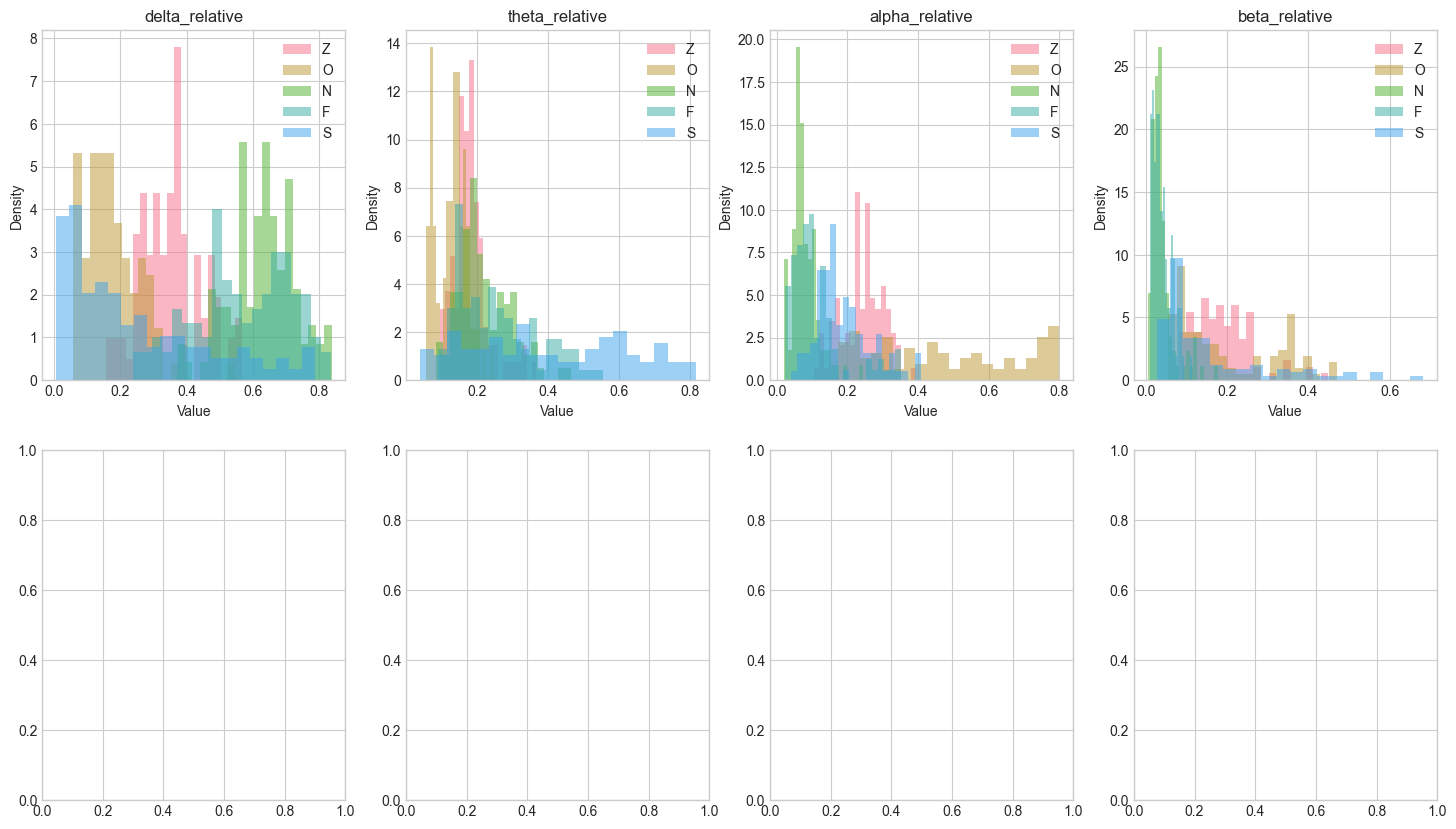

In [14]:
# Visualize feature distributions by class
important_features = ['delta_relative', 'theta_relative', 'alpha_relative', 'beta_relative',
                      'hjorth_activity', 'hjorth_mobility', 'line_length', 'spectral_entropy']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    for class_label in range(5):
        class_data = feature_df[feature_df['label'] == class_label][feature]
        class_name = list(CLASS_INFO.keys())[class_label]
        axes[idx].hist(class_data, bins=20, alpha=0.5, label=class_name, density=True)
    
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


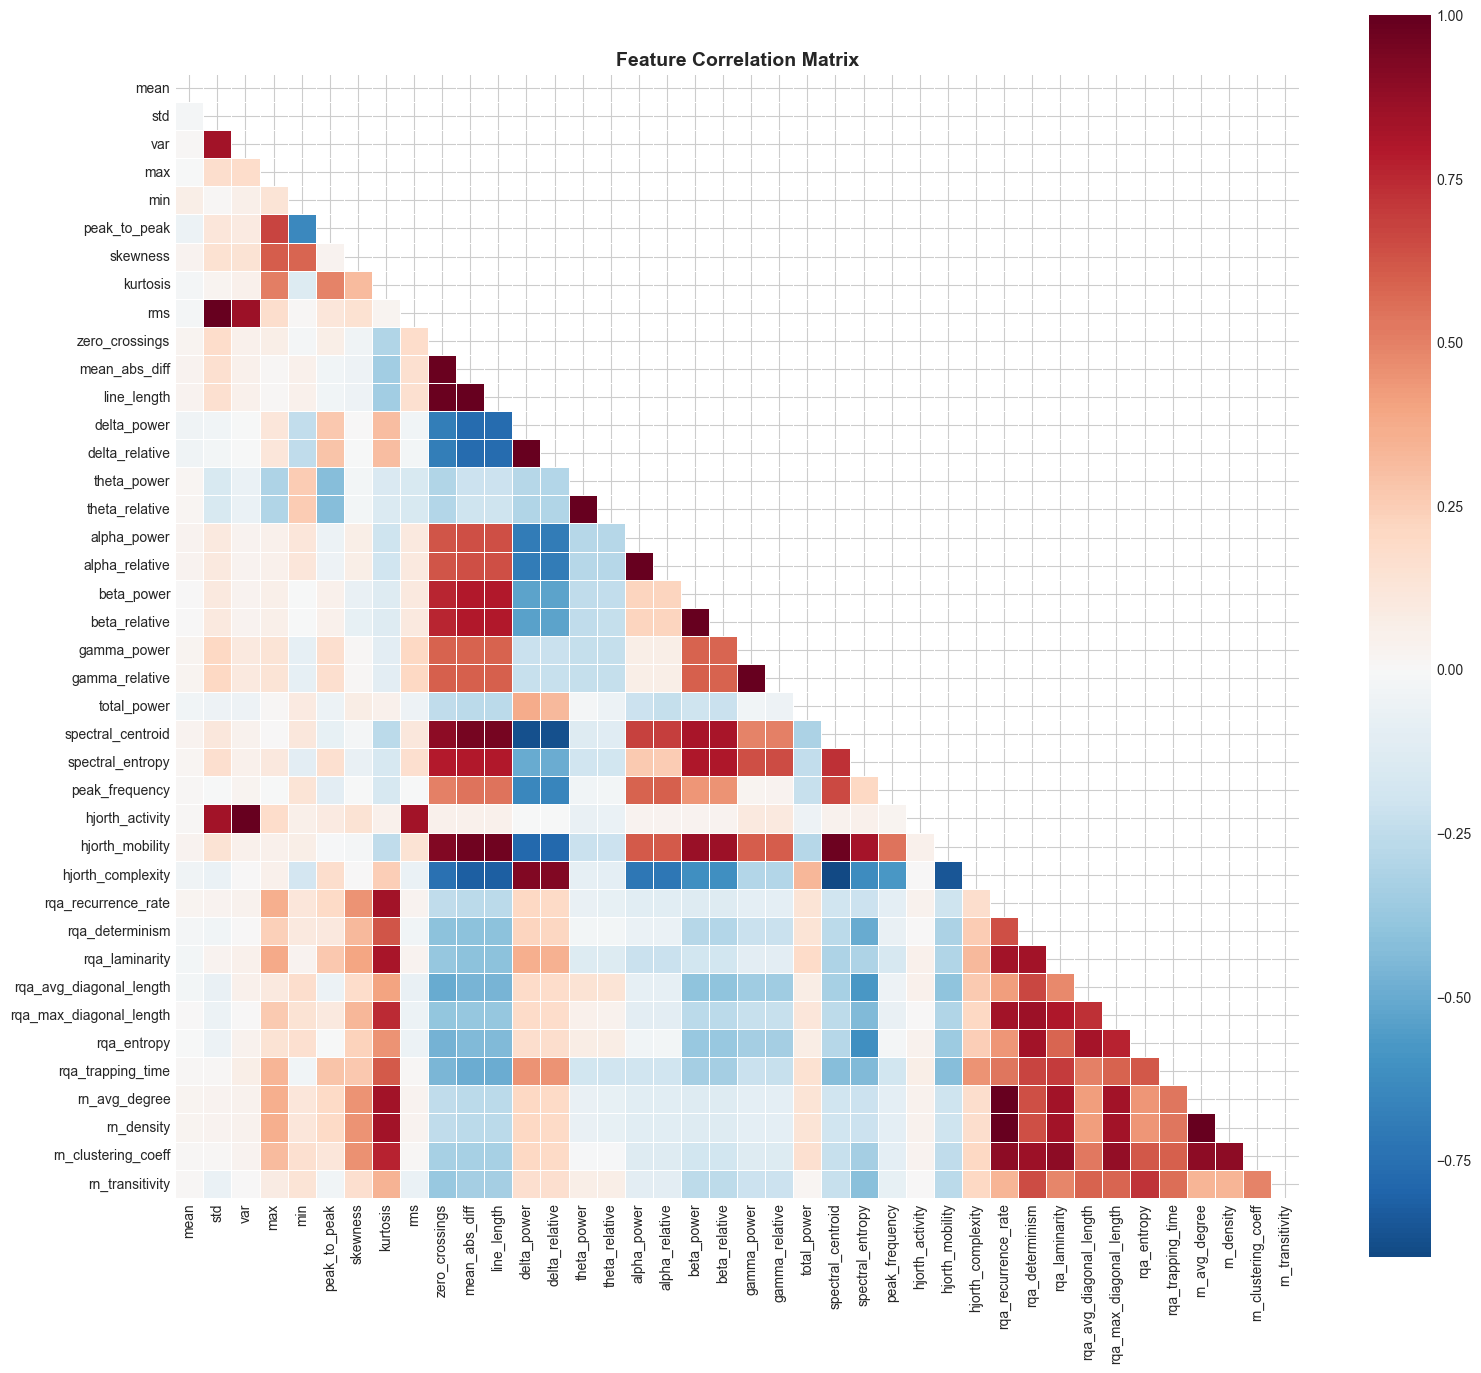

In [68]:
# Feature correlation heatmap
feature_cols = [col for col in feature_df.columns if col not in ['label', 'class']]
corr_matrix = feature_df[feature_cols].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 5.3 Data Augmentation

Data augmentation is crucial for improving model generalization, especially with limited training data. We implement several EEG-specific augmentation techniques:
- **Jittering**: Adding random noise
- **Scaling**: Amplitude scaling
- **Time Shifting**: Circular shifting of the signal
- **Permutation**: Segment permutation


Data augmentation functions defined!


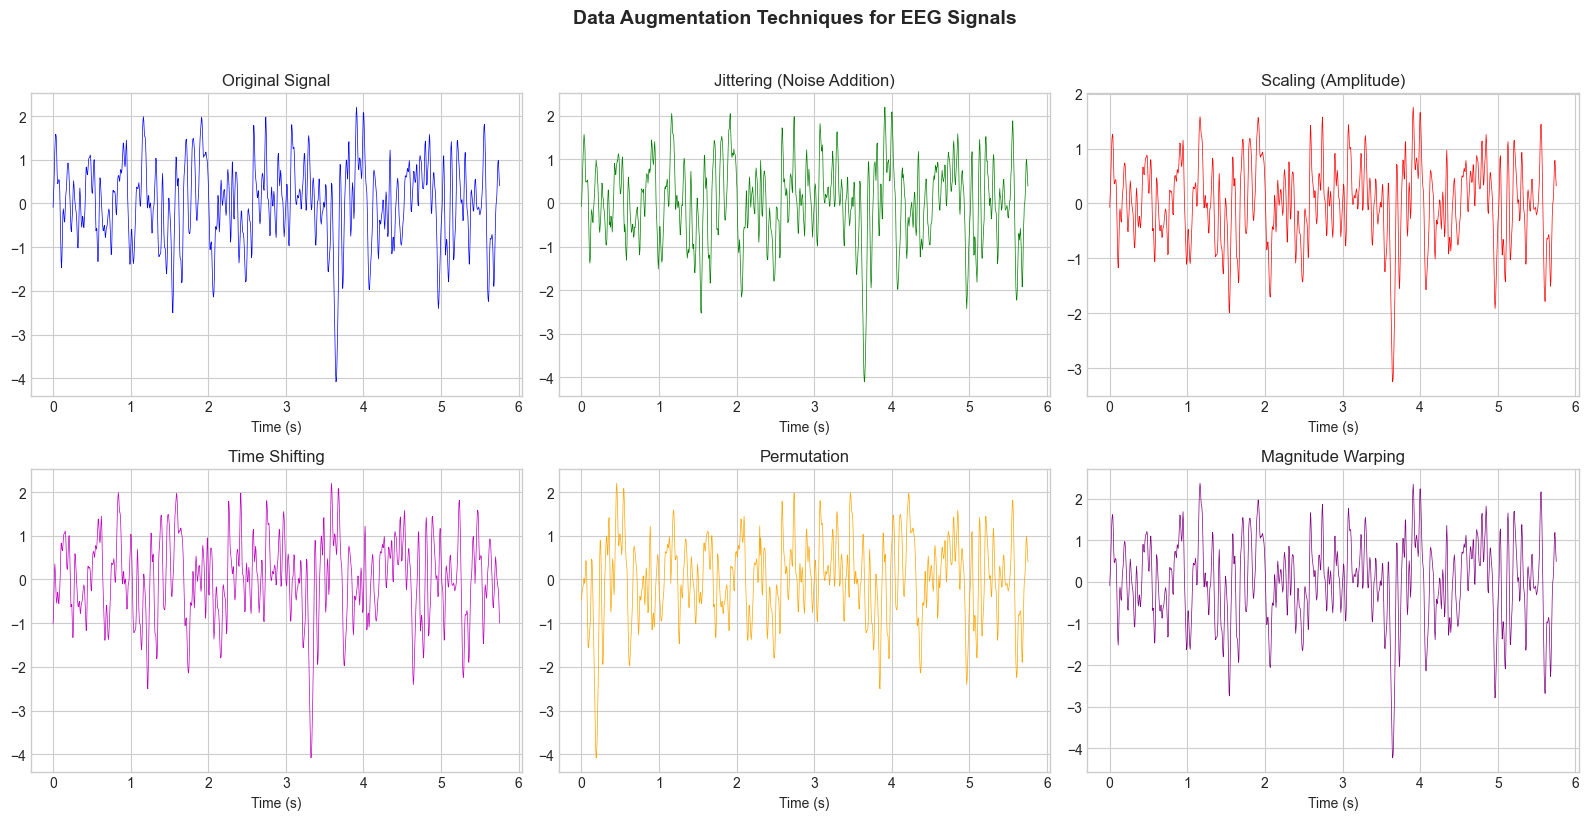

In [43]:
def augment_jitter(signal_data, sigma=0.05):
    """Add random Gaussian noise to the signal."""
    noise = np.random.normal(0, sigma, signal_data.shape)
    return signal_data + noise

def augment_scaling(signal_data, sigma=0.1):
    """Scale the signal by a random factor."""
    scale_factor = np.random.normal(1, sigma)
    return signal_data * scale_factor

def augment_time_shift(signal_data, max_shift=100):
    """Circular shift the signal by a random amount."""
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal_data, shift)

def augment_permutation(signal_data, n_segments=5):
    """Randomly permute segments of the signal."""
    segment_length = len(signal_data) // n_segments
    segments = [signal_data[i*segment_length:(i+1)*segment_length] for i in range(n_segments)]
    # Handle remainder
    remainder = signal_data[n_segments*segment_length:]
    
    np.random.shuffle(segments)
    permuted = np.concatenate(segments + [remainder])
    return permuted

def augment_magnitude_warp(signal_data, sigma=0.2, n_knots=4):
    """Smooth magnitude warping of the signal."""
    orig_steps = np.arange(len(signal_data))
    random_warps = np.random.normal(1, sigma, n_knots + 2)
    warp_steps = np.linspace(0, len(signal_data) - 1, n_knots + 2)
    warper = np.interp(orig_steps, warp_steps, random_warps)
    return signal_data * warper

def augment_signal(signal_data, augmentation_type='random'):
    """
    Apply augmentation to a signal.
    
    Parameters:
        signal_data: input signal
        augmentation_type: 'jitter', 'scaling', 'shift', 'permutation', 'warp', or 'random'
    """
    if augmentation_type == 'random':
        augmentation_type = np.random.choice(['jitter', 'scaling', 'shift', 'permutation', 'warp'])
    
    if augmentation_type == 'jitter':
        return augment_jitter(signal_data)
    elif augmentation_type == 'scaling':
        return augment_scaling(signal_data)
    elif augmentation_type == 'shift':
        return augment_time_shift(signal_data)
    elif augmentation_type == 'permutation':
        return augment_permutation(signal_data)
    elif augmentation_type == 'warp':
        return augment_magnitude_warp(signal_data)
    else:
        return signal_data

def augment_dataset(X, y, augmentation_factor=2):
    """
    Augment the entire dataset.
    
    Parameters:
        X: input data array of shape (n_samples, n_timepoints)
        y: labels array
        augmentation_factor: how many augmented versions to create per sample
    
    Returns:
        X_augmented: augmented data
        y_augmented: corresponding labels
    """
    X_augmented = [X]
    y_augmented = [y]
    
    for _ in range(augmentation_factor):
        X_aug = np.array([augment_signal(x, 'random') for x in X])
        X_augmented.append(X_aug)
        y_augmented.append(y.copy())
    
    return np.vstack(X_augmented), np.concatenate(y_augmented)

print("Data augmentation functions defined!")

# Visualize augmentation effects on a sample signal
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sample_signal = preprocessed_data[0][:1000]
time_sample = time[:1000]

# Original
axes[0, 0].plot(time_sample, sample_signal, 'b-', linewidth=0.5)
axes[0, 0].set_title('Original Signal')
axes[0, 0].set_xlabel('Time (s)')

# Jittering
axes[0, 1].plot(time_sample, augment_jitter(sample_signal), 'g-', linewidth=0.5)
axes[0, 1].set_title('Jittering (Noise Addition)')
axes[0, 1].set_xlabel('Time (s)')

# Scaling
axes[0, 2].plot(time_sample, augment_scaling(sample_signal), 'r-', linewidth=0.5)
axes[0, 2].set_title('Scaling (Amplitude)')
axes[0, 2].set_xlabel('Time (s)')

# Time Shift
axes[1, 0].plot(time_sample, augment_time_shift(sample_signal), 'm-', linewidth=0.5)
axes[1, 0].set_title('Time Shifting')
axes[1, 0].set_xlabel('Time (s)')

# Permutation
axes[1, 1].plot(time_sample, augment_permutation(sample_signal), 'orange', linewidth=0.5)
axes[1, 1].set_title('Permutation')
axes[1, 1].set_xlabel('Time (s)')

# Magnitude Warp
axes[1, 2].plot(time_sample, augment_magnitude_warp(sample_signal), 'purple', linewidth=0.5)
axes[1, 2].set_title('Magnitude Warping')
axes[1, 2].set_xlabel('Time (s)')

plt.suptitle('Data Augmentation Techniques for EEG Signals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 6. Data Splitting


In [44]:
# Prepare labels
y = labels.copy()

# Split preprocessed signal data: 70% train, 15% validation, 15% test
X_raw_train, X_raw_temp, y_raw_train, y_raw_temp = train_test_split(
    preprocessed_data, y, test_size=0.3, random_state=42, stratify=y
)

X_raw_val, X_raw_test, y_raw_val, y_raw_test = train_test_split(
    X_raw_temp, y_raw_temp, test_size=0.5, random_state=42, stratify=y_raw_temp
)

print("=== Data Split Summary ===")
print(f"Total samples: {len(preprocessed_data)}")
print(f"Signal length: {preprocessed_data.shape[1]} time points")
print(f"\nTraining set: {len(X_raw_train)} samples ({len(X_raw_train)/len(y)*100:.1f}%)")
print(f"Validation set: {len(X_raw_val)} samples ({len(X_raw_val)/len(y)*100:.1f}%)")
print(f"Test set: {len(X_raw_test)} samples ({len(X_raw_test)/len(y)*100:.1f}%)")

# Apply data augmentation to training data only
print("\n=== Applying Data Augmentation to Training Set ===")
AUGMENTATION_FACTOR = 3  # Create 3 augmented versions of each training sample

X_raw_train_aug, y_raw_train_aug = augment_dataset(X_raw_train, y_raw_train, AUGMENTATION_FACTOR)

print(f"Original training set size: {len(X_raw_train)} samples")
print(f"Augmented training set size: {len(X_raw_train_aug)} samples ({AUGMENTATION_FACTOR+1}x)")
print(f"Validation set size (unchanged): {len(X_raw_val)} samples")
print(f"Test set size (unchanged): {len(X_raw_test)} samples")


=== Data Split Summary ===
Total samples: 500
Signal length: 4097 time points

Training set: 350 samples (70.0%)
Validation set: 75 samples (15.0%)
Test set: 75 samples (15.0%)

=== Applying Data Augmentation to Training Set ===
Original training set size: 350 samples
Augmented training set size: 1400 samples (4x)
Validation set size (unchanged): 75 samples
Test set size (unchanged): 75 samples


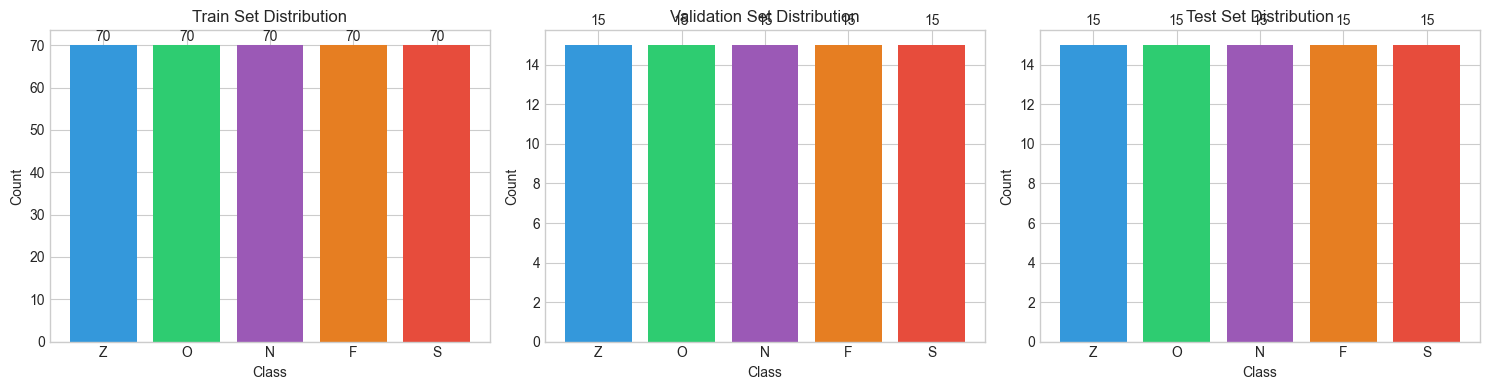

In [45]:
# Visualize train/val/test split distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, data) in zip(axes, [('Train', y_raw_train), ('Validation', y_raw_val), ('Test', y_raw_test)]):
    unique, counts = np.unique(data, return_counts=True)
    class_labels = [list(CLASS_INFO.keys())[i] for i in unique]
    ax.bar(class_labels, counts, color=colors)
    ax.set_title(f'{name} Set Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    for i, (label, count) in enumerate(zip(class_labels, counts)):
        ax.text(i, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()


---
## 7. Deep Learning Model Selection and Training

We will use two deep learning architectures optimized for EEG signal classification:
- **1D Convolutional Neural Network (CNN)**: Captures local patterns and features in the temporal signal
- **Bidirectional LSTM**: Captures long-term temporal dependencies in the EEG data


### 7.1 Data Preparation for Deep Learning


In [46]:
# Prepare data for CNN using AUGMENTED training data
# Reshape for CNN: (samples, timesteps, features)
X_cnn_train = X_raw_train_aug.reshape(-1, X_raw_train_aug.shape[1], 1)  # Using augmented data
X_cnn_val = X_raw_val.reshape(-1, X_raw_val.shape[1], 1)
X_cnn_test = X_raw_test.reshape(-1, X_raw_test.shape[1], 1)

# One-hot encode labels
y_cnn_train = to_categorical(y_raw_train_aug, num_classes=5)  # Using augmented labels
y_cnn_val = to_categorical(y_raw_val, num_classes=5)
y_cnn_test = to_categorical(y_raw_test, num_classes=5)

print(f"CNN Training Input shape (augmented): {X_cnn_train.shape}")
print(f"CNN Training Output shape (augmented): {y_cnn_train.shape}")
print(f"CNN Validation Input shape: {X_cnn_val.shape}")
print(f"CNN Test Input shape: {X_cnn_test.shape}")


CNN Training Input shape (augmented): (1400, 4097, 1)
CNN Training Output shape (augmented): (1400, 5)
CNN Validation Input shape: (75, 4097, 1)
CNN Test Input shape: (75, 4097, 1)


In [47]:
from tensorflow.keras.regularizers import l2

def build_improved_cnn_model(input_shape, num_classes=5):
    """
    Build an improved 1D CNN model for EEG classification.
    
    Improvements:
    - L2 regularization to prevent overfitting
    - Smaller initial filters with gradual increase
    - More aggressive pooling to reduce dimensionality
    - Lower initial learning rate
    """
    reg = l2(0.001)  # L2 regularization
    
    model = Sequential([
        # First Conv Block - capture local patterns
        Conv1D(32, kernel_size=7, activation='relu', input_shape=input_shape, 
               padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),  # Aggressive pooling
        Dropout(0.2),
        
        # Second Conv Block
        Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),
        Dropout(0.25),
        
        # Third Conv Block
        Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        MaxPooling1D(pool_size=4),
        Dropout(0.3),
        
        # Fourth Conv Block
        Conv1D(256, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        
        # Dense layers with regularization
        Dense(128, activation='relu', kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(64, activation='relu', kernel_regularizer=reg),
        Dropout(0.3),
        
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Lower learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build improved CNN model
print("Building improved CNN model...")
cnn_model = build_improved_cnn_model((X_cnn_train.shape[1], 1))
cnn_model.summary()


Building improved CNN model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 4097, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 4097, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1024, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 256, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 64, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,733 (694.27 KB)

 Trainable params: 176,517 (689.52 KB)

 Non-trainable params: 1,216 (4.75 KB)

In [48]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train CNN
print("\n=== Training CNN Model ===")
history_cnn = cnn_model.fit(
    X_cnn_train, y_cnn_train,
    validation_data=(X_cnn_val, y_cnn_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)



=== Training CNN Model ===
Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5686 - loss: 1.6418 - val_accuracy: 0.1600 - val_loss: 2.2732 - learning_rate: 5.0000e-04
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7029 - loss: 1.2753 - val_accuracy: 0.2000 - val_loss: 2.5751 - learning_rate: 5.0000e-04
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7329 - loss: 1.1748 - val_accuracy: 0.2000 - val_loss: 2.8371 - learning_rate: 5.0000e-04
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7693 - loss: 1.1112 - val_accuracy: 0.2000 - val_loss: 3.1841 - learning_rate: 5.0000e-04
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7957 - loss: 1.0258 - val_accuracy: 0.2000 - val_loss: 3.5518 - learning_rate: 5.0000e-04
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.7972 - loss: 1.0078
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 

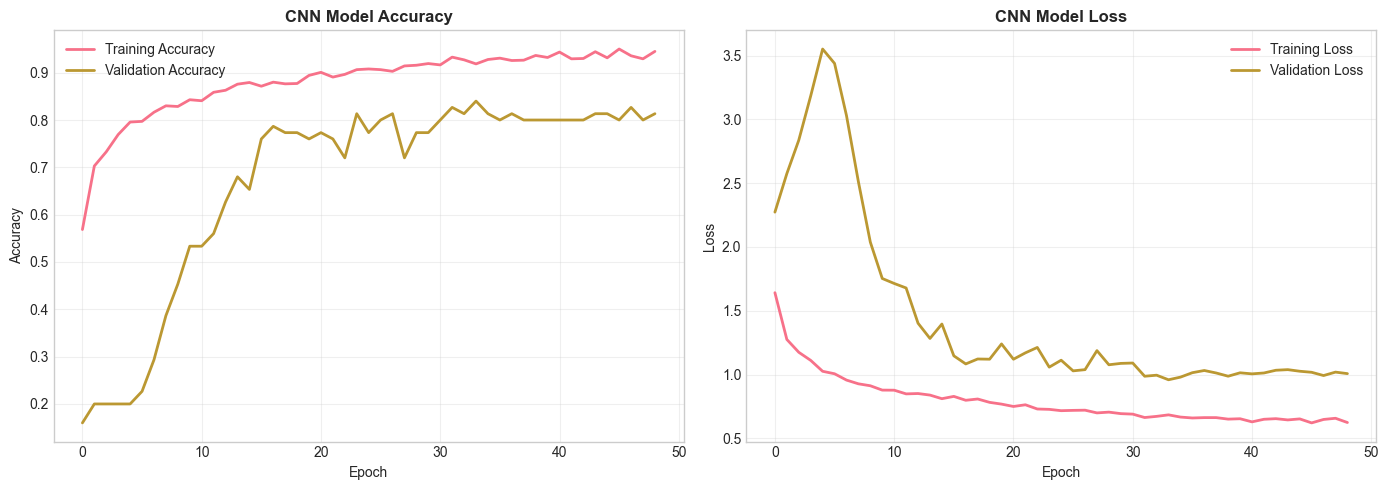

In [49]:
# Plot training history for CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_cnn.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('CNN Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cnn.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('CNN Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [50]:
def build_improved_lstm_model(input_shape, num_classes=5):
    """
    Build an improved Bidirectional LSTM model for EEG classification.
    
    Improvements:
    - L2 regularization in LSTM layers
    - Recurrent dropout for better regularization
    - Gradual reduction in LSTM units
    - Lower learning rate
    """
    reg = l2(0.001)
    
    model = Sequential([
        # First Bidirectional LSTM layer
        Bidirectional(LSTM(64, return_sequences=True, 
                          kernel_regularizer=reg, recurrent_dropout=0.1), 
                     input_shape=input_shape),
        BatchNormalization(),
        Dropout(0.25),
        
        # Second Bidirectional LSTM layer
        Bidirectional(LSTM(32, return_sequences=True, 
                          kernel_regularizer=reg, recurrent_dropout=0.1)),
        BatchNormalization(),
        Dropout(0.25),
        
        # Third Bidirectional LSTM layer (output layer)
        Bidirectional(LSTM(16, kernel_regularizer=reg)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Dense layers with regularization
        Dense(64, activation='relu', kernel_regularizer=reg),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu', kernel_regularizer=reg),
        Dropout(0.2),
        
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Lower learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# For LSTM, we'll downsample the signal to reduce sequence length
# Downsample from 4097 to 256 points (more aggressive for LSTM efficiency)
def downsample_signal(data, target_length=256):
    indices = np.linspace(0, data.shape[1]-1, target_length, dtype=int)
    return data[:, indices]

# Use AUGMENTED training data for LSTM
X_lstm_train = downsample_signal(X_raw_train_aug).reshape(-1, 256, 1)
X_lstm_val = downsample_signal(X_raw_val).reshape(-1, 256, 1)
X_lstm_test = downsample_signal(X_raw_test).reshape(-1, 256, 1)

print(f"LSTM Training Input shape (augmented): {X_lstm_train.shape}")
print(f"LSTM Validation Input shape: {X_lstm_val.shape}")
print(f"LSTM Test Input shape: {X_lstm_test.shape}")

# Build improved LSTM model
print("\nBuilding improved LSTM model...")
lstm_model = build_improved_lstm_model((256, 1))
lstm_model.summary()


LSTM Training Input shape (augmented): (1400, 256, 1)
LSTM Validation Input shape: (75, 256, 1)
LSTM Test Input shape: (75, 256, 1)

Building improved LSTM model...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 256, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256, 64)        │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,885 (355.02 KB)

 Trainable params: 90,309 (352.77 KB)

 Non-trainable params: 576 (2.25 KB)

In [51]:
# Callbacks for LSTM
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train LSTM
print("\n=== Training LSTM Model ===")
history_lstm = lstm_model.fit(
    X_lstm_train, y_cnn_train,
    validation_data=(X_lstm_val, y_cnn_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_lstm,
    verbose=1
)



=== Training LSTM Model ===
Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step - accuracy: 0.2179 - loss: 2.6842 - val_accuracy: 0.2000 - val_loss: 2.0868 - learning_rate: 5.0000e-04
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 165ms/step - accuracy: 0.2500 - loss: 2.3894 - val_accuracy: 0.2000 - val_loss: 2.0884 - learning_rate: 5.0000e-04
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.2393 - loss: 2.3268 - val_accuracy: 0.2000 - val_loss: 2.0948 - learning_rate: 5.0000e-04
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 251ms/step - accuracy: 0.2643 - loss: 2.2335 - val_accuracy: 0.2000 - val_loss: 2.1166 - learning_rate: 5.0000e-04
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.2929 - loss: 2.1667 - val_accuracy: 0.1733 - val_loss: 2.1059 - learning_rate: 5.0000e-04
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 262ms/step - accuracy: 0.3007 - loss: 2.1197 - val_accuracy: 0.2667 - val_loss: 2.0744 - learning_rate: 5.0000e-04
Epoch 7/50
44/44 ━━━━━━━━━━━━━

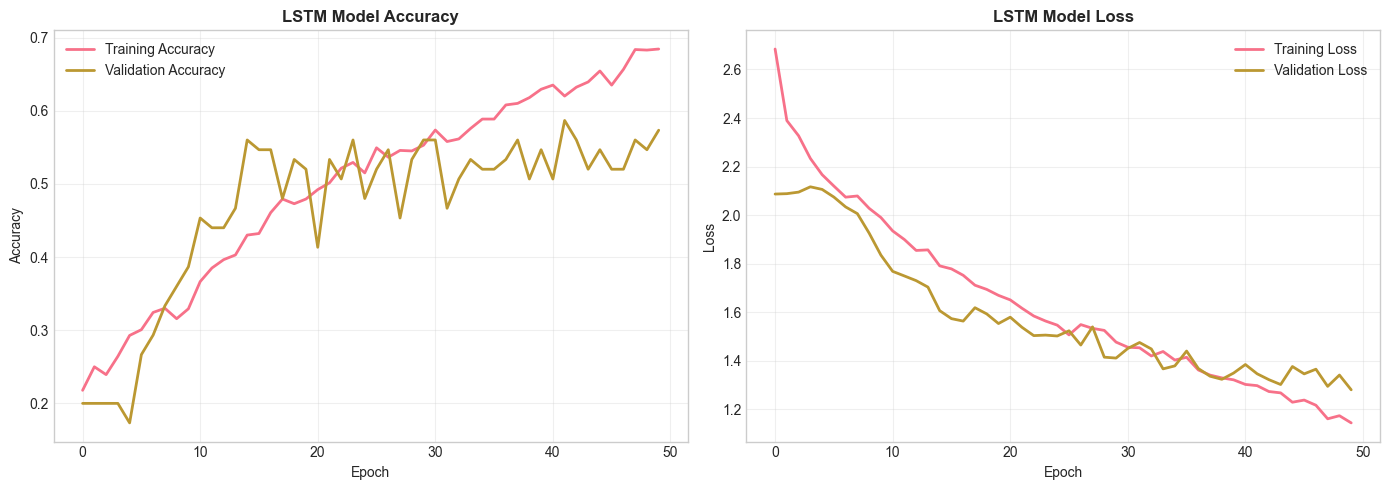

In [52]:
# Plot training history for LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('LSTM Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('LSTM Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 8. Model Evaluation


In [53]:
def evaluate_model(y_true, y_pred, model_name, class_names_list):
    """
    Comprehensive model evaluation with metrics and visualizations.
    """
    print(f"\n{'='*60}")
    print(f"Evaluation Results: {model_name}")
    print('='*60)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\nOverall Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    # Classification report
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names_list))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

def plot_confusion_matrix(cm, class_names_list, title):
    """
    Plot confusion matrix.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_list, yticklabels=class_names_list)
    plt.title(f'Confusion Matrix - {title}', fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Class names for visualization
class_names_list = ['Z (Normal)', 'O (Normal)', 'N (Interictal)', 'F (Interictal)', 'S (Seizure)']


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Evaluation Results: CNN

Overall Metrics:
  Accuracy:  0.8400
  Precision: 0.8868
  Recall:    0.8400
  F1-Score:  0.8347

Classification Report:
                precision    recall  f1-score   support

    Z (Normal)       1.00      0.93      0.97        15
    O (Normal)       1.00      0.93      0.97        15
N (Interictal)       0.58      1.00      0.73        15
F (Interictal)       0.86      0.40      0.55        15
   S (Seizure)       1.00      0.93      0.97        15

      accuracy                           0.84        75
     macro avg       0.89      0.84      0.83        75
  weighted avg       0.89      0.84      0.83        75



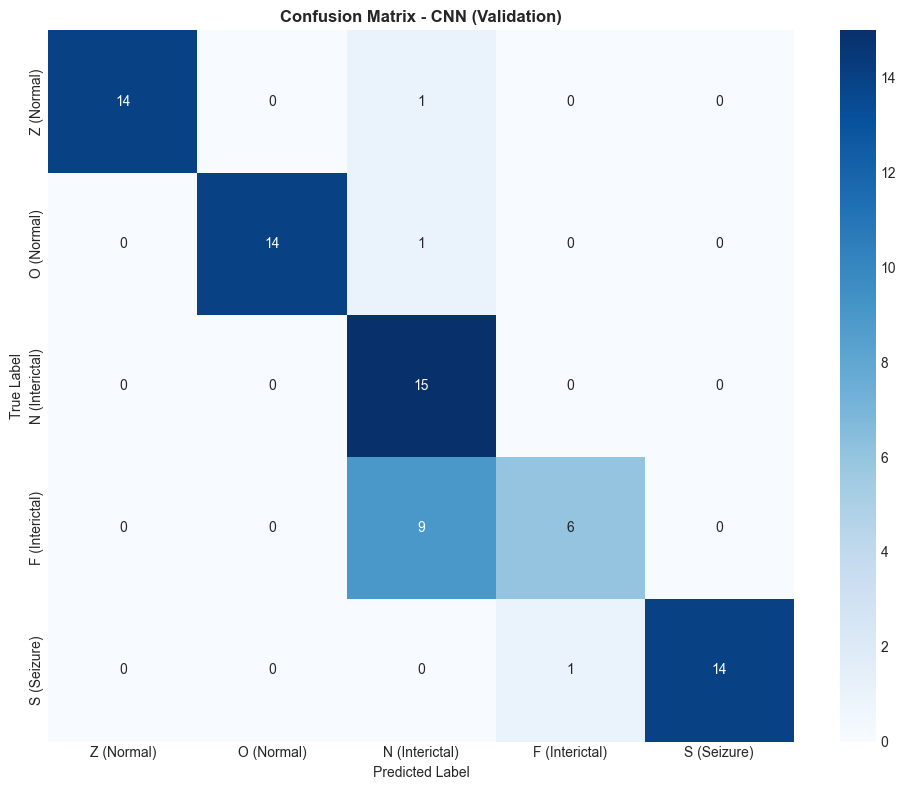

In [54]:
# Evaluate CNN
y_pred_cnn = cnn_model.predict(X_cnn_val)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)
cnn_results = evaluate_model(y_raw_val, y_pred_cnn_classes, 'CNN', class_names_list)
plot_confusion_matrix(cnn_results['confusion_matrix'], class_names_list, 
                      'CNN (Validation)')


1/3 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/stepWARNING:tensorflow:5 out of the last 19 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x1656adc60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step

Evaluation Results: LSTM

Overall Metrics:
  Accuracy:  0.5733
  Precision: 0.5827
  Recall:    0.5733
  F1-Score:  0.5739

Classification Report:
                precision    recall  f1-score   support

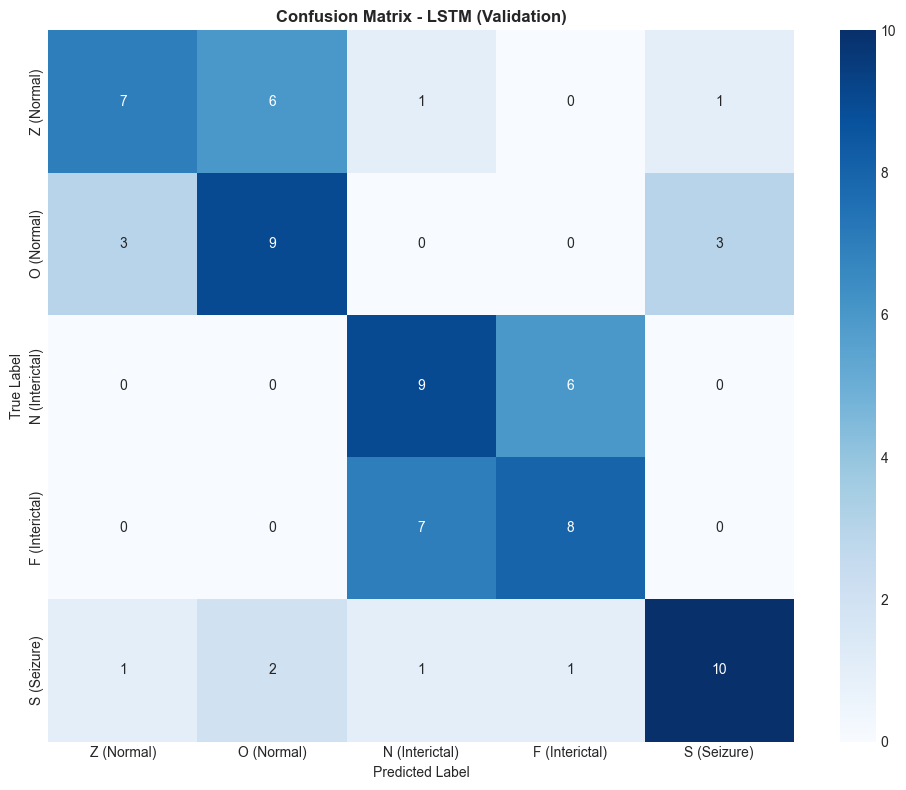

In [55]:
# Evaluate LSTM
y_pred_lstm = lstm_model.predict(X_lstm_val)
y_pred_lstm_classes = np.argmax(y_pred_lstm, axis=1)
lstm_results = evaluate_model(y_raw_val, y_pred_lstm_classes, 'LSTM', class_names_list)
plot_confusion_matrix(lstm_results['confusion_matrix'], class_names_list, 
                      'LSTM (Validation)')


In [56]:
# Deep Learning Model Comparison
comparison_data = {
    'Model': ['CNN', 'LSTM'],
    'Accuracy': [cnn_results['accuracy'], lstm_results['accuracy']],
    'Precision': [cnn_results['precision'], lstm_results['precision']],
    'Recall': [cnn_results['recall'], lstm_results['recall']],
    'F1-Score': [cnn_results['f1'], lstm_results['f1']]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n=== Deep Learning Model Comparison (Validation Set) ===")
print(comparison_df.to_string(index=False))

# Identify best model
best_val_model = comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']
print(f"\n🏆 Best performing model on validation: {best_val_model}")



=== Deep Learning Model Comparison (Validation Set) ===
Model  Accuracy  Precision   Recall  F1-Score
  CNN  0.840000   0.886813 0.840000  0.834743
 LSTM  0.573333   0.582679 0.573333  0.573881

🏆 Best performing model on validation: CNN


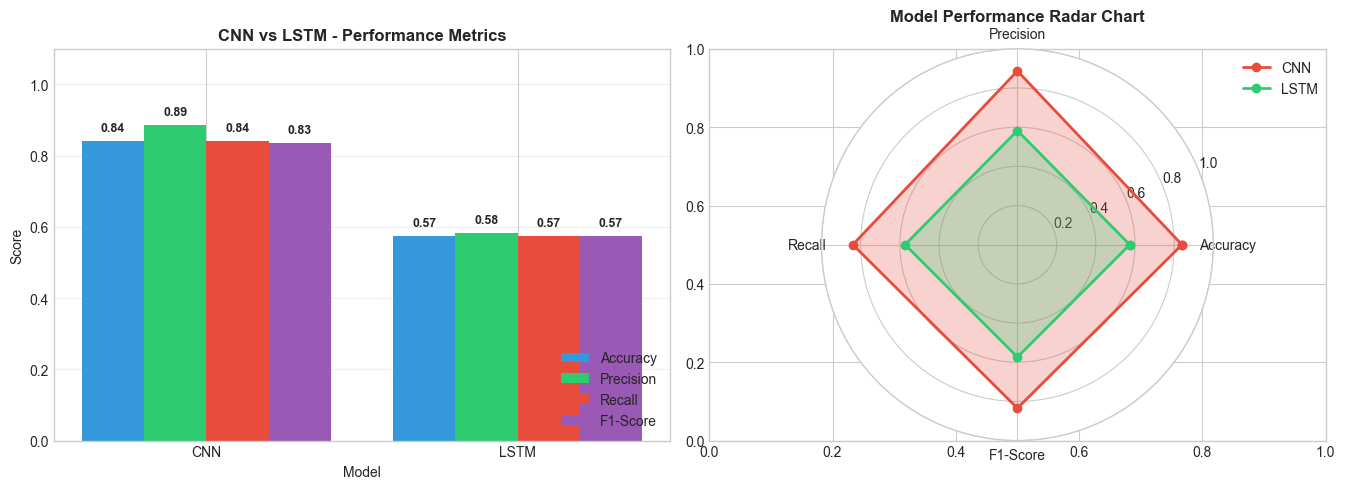

In [57]:
# Visualize Deep Learning model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_metrics = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, metric in enumerate(metrics):
    ax1.bar(x + i*width, comparison_df[metric], width, label=metric, color=colors_metrics[i])

ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('CNN vs LSTM - Performance Metrics', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(comparison_df['Model'])
ax1.legend(loc='lower right')
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, metric in enumerate(metrics):
    for j, v in enumerate(comparison_df[metric]):
        ax1.text(j + i*width, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Radar chart for comparison
ax2 = axes[1]
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)

# Create angles for radar chart
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

# CNN values
cnn_values = [cnn_results['accuracy'], cnn_results['precision'], cnn_results['recall'], cnn_results['f1']]
cnn_values += cnn_values[:1]

# LSTM values
lstm_values = [lstm_results['accuracy'], lstm_results['precision'], lstm_results['recall'], lstm_results['f1']]
lstm_values += lstm_values[:1]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, cnn_values, 'o-', linewidth=2, label='CNN', color='#e74c3c')
ax2.fill(angles, cnn_values, alpha=0.25, color='#e74c3c')
ax2.plot(angles, lstm_values, 'o-', linewidth=2, label='LSTM', color='#2ecc71')
ax2.fill(angles, lstm_values, alpha=0.25, color='#2ecc71')

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)
ax2.set_ylim(0, 1)
ax2.set_title('Model Performance Radar Chart', fontsize=12, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()


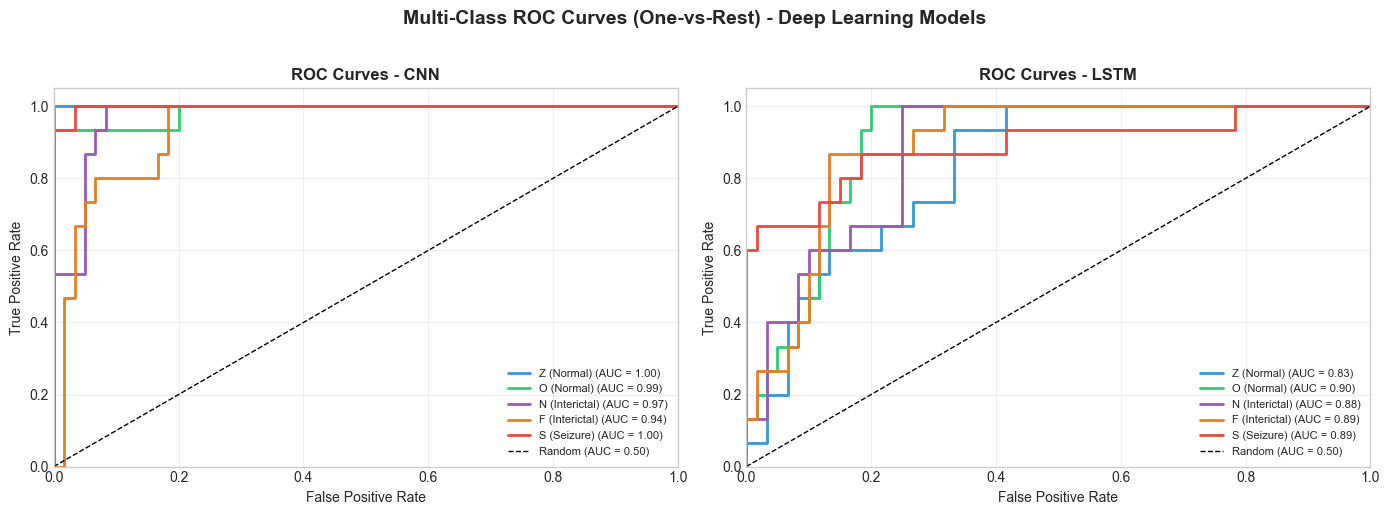


=== Macro-Average AUC Scores ===
   CNN: 0.9800
   LSTM: 0.8787


In [58]:
# ROC Curves for Deep Learning Models (One-vs-Rest)
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binarize the validation labels for ROC curve calculation
y_raw_val_bin = label_binarize(y_raw_val, classes=[0, 1, 2, 3, 4])

# Get prediction probabilities
cnn_probs = cnn_model.predict(X_cnn_val, verbose=0)
lstm_probs = lstm_model.predict(X_lstm_val, verbose=0)

models_roc = [
    ('CNN', cnn_probs, y_raw_val_bin),
    ('LSTM', lstm_probs, y_raw_val_bin)
]

class_colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

for ax_idx, (model_name, probs, y_true_bin) in enumerate(models_roc):
    ax = axes[ax_idx]
    
    # Calculate ROC curve for each class
    for i, class_name in enumerate(class_names_list):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=class_colors[i], lw=2, 
                label=f'{class_name} (AUC = {roc_auc:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves - {model_name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Multi-Class ROC Curves (One-vs-Rest) - Deep Learning Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Calculate and print macro-average AUC for each model
print("\n=== Macro-Average AUC Scores ===")
for model_name, probs, y_true_bin in models_roc:
    macro_auc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovr')
    print(f"   {model_name}: {macro_auc:.4f}")


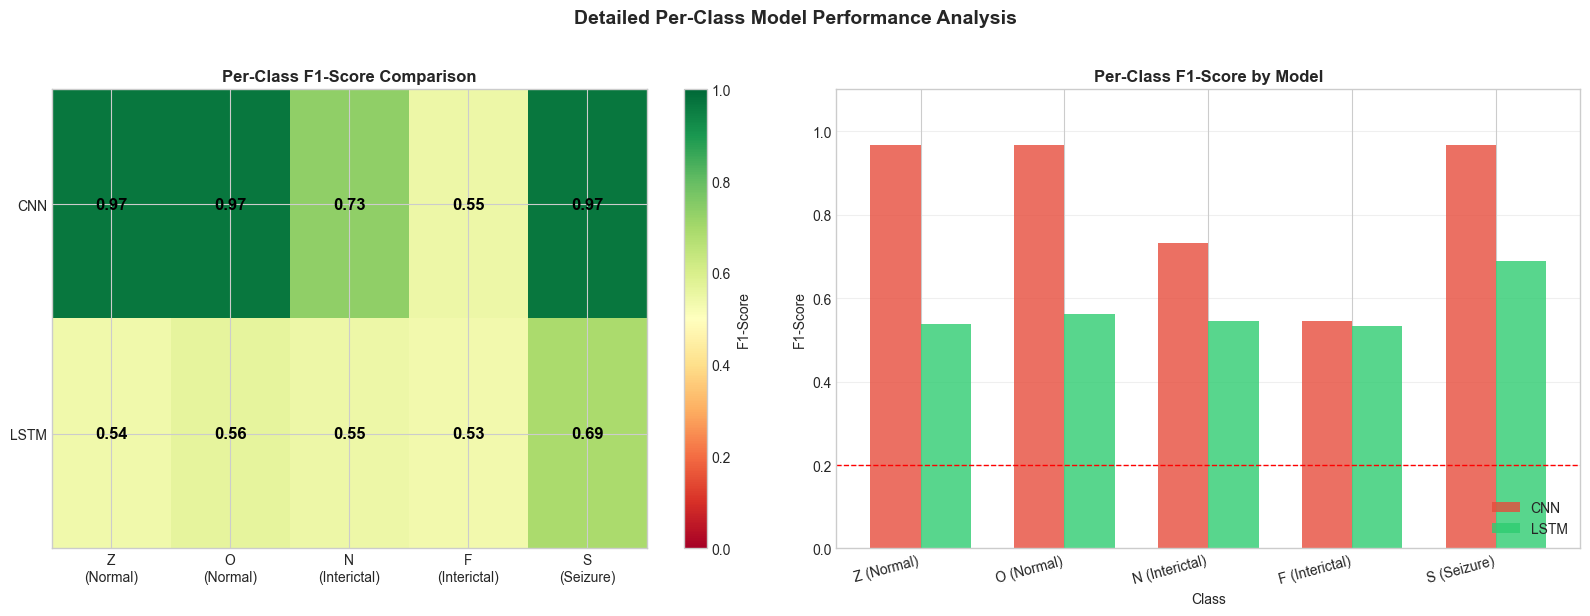


📊 Per-Class Performance Insights:
   • Best model for Normal classes (Z, O): Check heatmap for highest F1
   • Interictal classes (N, F) are typically hardest to distinguish
   • Seizure class (S) usually has high detection accuracy due to distinct patterns


In [59]:
# Per-Class Performance Comparison Heatmap (Deep Learning Models)
from sklearn.metrics import precision_recall_fscore_support

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calculate per-class metrics for each model
models_eval = [
    ('CNN', y_raw_val, y_pred_cnn_classes),
    ('LSTM', y_raw_val, y_pred_lstm_classes)
]

# Create per-class F1 score heatmap
f1_matrix = []
model_names_eval = []

for model_name, y_true, y_pred in models_eval:
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    f1_matrix.append(f1)
    model_names_eval.append(model_name)

f1_matrix = np.array(f1_matrix)

# Heatmap of F1 scores
ax1 = axes[0]
im = ax1.imshow(f1_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Add text annotations
for i in range(len(model_names_eval)):
    for j in range(5):
        text = ax1.text(j, i, f'{f1_matrix[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax1.set_xticks(range(5))
ax1.set_xticklabels(['Z\n(Normal)', 'O\n(Normal)', 'N\n(Interictal)', 'F\n(Interictal)', 'S\n(Seizure)'])
ax1.set_yticks(range(len(model_names_eval)))
ax1.set_yticklabels(model_names_eval)
ax1.set_title('Per-Class F1-Score Comparison', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax1, label='F1-Score')

# Grouped bar chart for per-class comparison (best model focus)
ax2 = axes[1]

x = np.arange(5)
width = 0.35

for idx, (model_name, f1_scores) in enumerate(zip(model_names_eval, f1_matrix)):
    offset = (idx - 0.5) * width
    bars = ax2.bar(x + offset, f1_scores, width, label=model_name, alpha=0.8,
                   color=['#e74c3c', '#2ecc71'][idx])

ax2.set_xlabel('Class')
ax2.set_ylabel('F1-Score')
ax2.set_title('Per-Class F1-Score by Model', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Z (Normal)', 'O (Normal)', 'N (Interictal)', 'F (Interictal)', 'S (Seizure)'], 
                    rotation=15, ha='right')
ax2.legend(loc='lower right')
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3, axis='y')

# Add horizontal line for random performance
ax2.axhline(y=0.2, color='red', linestyle='--', linewidth=1, label='Random Baseline')

plt.suptitle('Detailed Per-Class Model Performance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print insights
print("\n📊 Per-Class Performance Insights:")
print("   • Best model for Normal classes (Z, O): Check heatmap for highest F1")
print("   • Interictal classes (N, F) are typically hardest to distinguish")
print("   • Seizure class (S) usually has high detection accuracy due to distinct patterns")


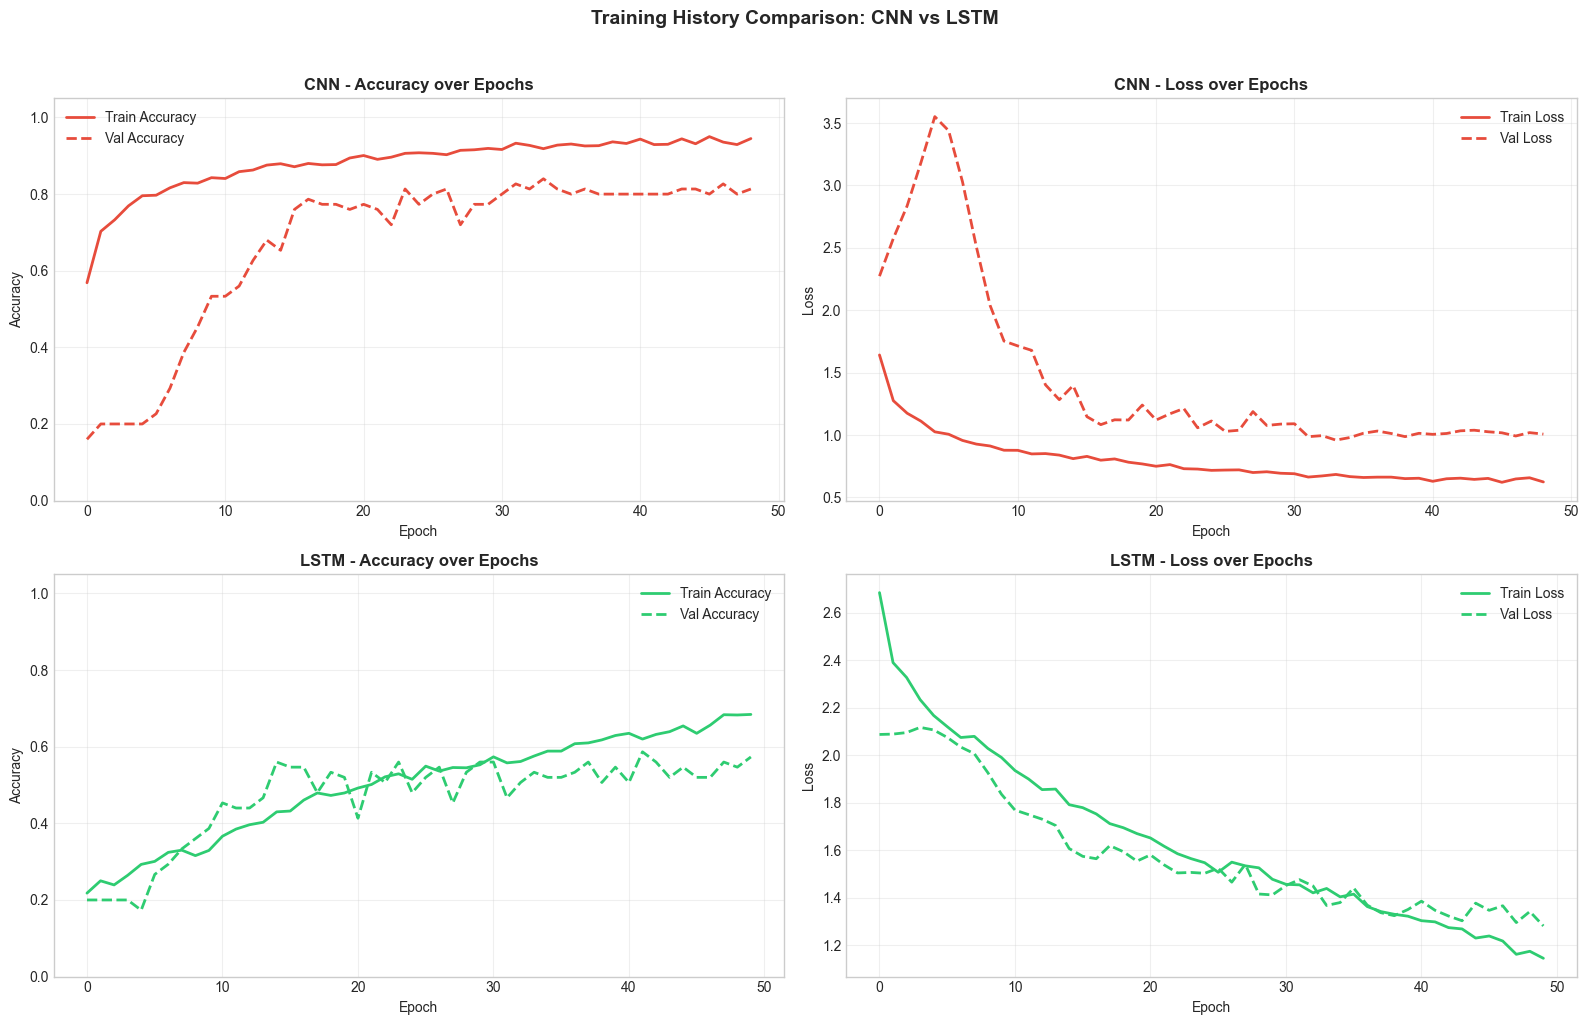


=== Training Summary ===
CNN  - Final Train Acc: 0.9450, Final Val Acc: 0.8133
LSTM - Final Train Acc: 0.6843, Final Val Acc: 0.5733

CNN trained for 49 epochs
LSTM trained for 50 epochs


In [60]:
# Training History Comparison: CNN vs LSTM
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# CNN Training History
axes[0, 0].plot(history_cnn.history['accuracy'], label='Train Accuracy', linewidth=2, color='#e74c3c')
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#e74c3c', linestyle='--')
axes[0, 0].set_title('CNN - Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 1.05])

axes[0, 1].plot(history_cnn.history['loss'], label='Train Loss', linewidth=2, color='#e74c3c')
axes[0, 1].plot(history_cnn.history['val_loss'], label='Val Loss', linewidth=2, color='#e74c3c', linestyle='--')
axes[0, 1].set_title('CNN - Loss over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# LSTM Training History
axes[1, 0].plot(history_lstm.history['accuracy'], label='Train Accuracy', linewidth=2, color='#2ecc71')
axes[1, 0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#2ecc71', linestyle='--')
axes[1, 0].set_title('LSTM - Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

axes[1, 1].plot(history_lstm.history['loss'], label='Train Loss', linewidth=2, color='#2ecc71')
axes[1, 1].plot(history_lstm.history['val_loss'], label='Val Loss', linewidth=2, color='#2ecc71', linestyle='--')
axes[1, 1].set_title('LSTM - Loss over Epochs', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training History Comparison: CNN vs LSTM', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print training summary
print("\n=== Training Summary ===")
print(f"CNN  - Final Train Acc: {history_cnn.history['accuracy'][-1]:.4f}, Final Val Acc: {history_cnn.history['val_accuracy'][-1]:.4f}")
print(f"LSTM - Final Train Acc: {history_lstm.history['accuracy'][-1]:.4f}, Final Val Acc: {history_lstm.history['val_accuracy'][-1]:.4f}")
print(f"\nCNN trained for {len(history_cnn.history['accuracy'])} epochs")
print(f"LSTM trained for {len(history_lstm.history['accuracy'])} epochs")


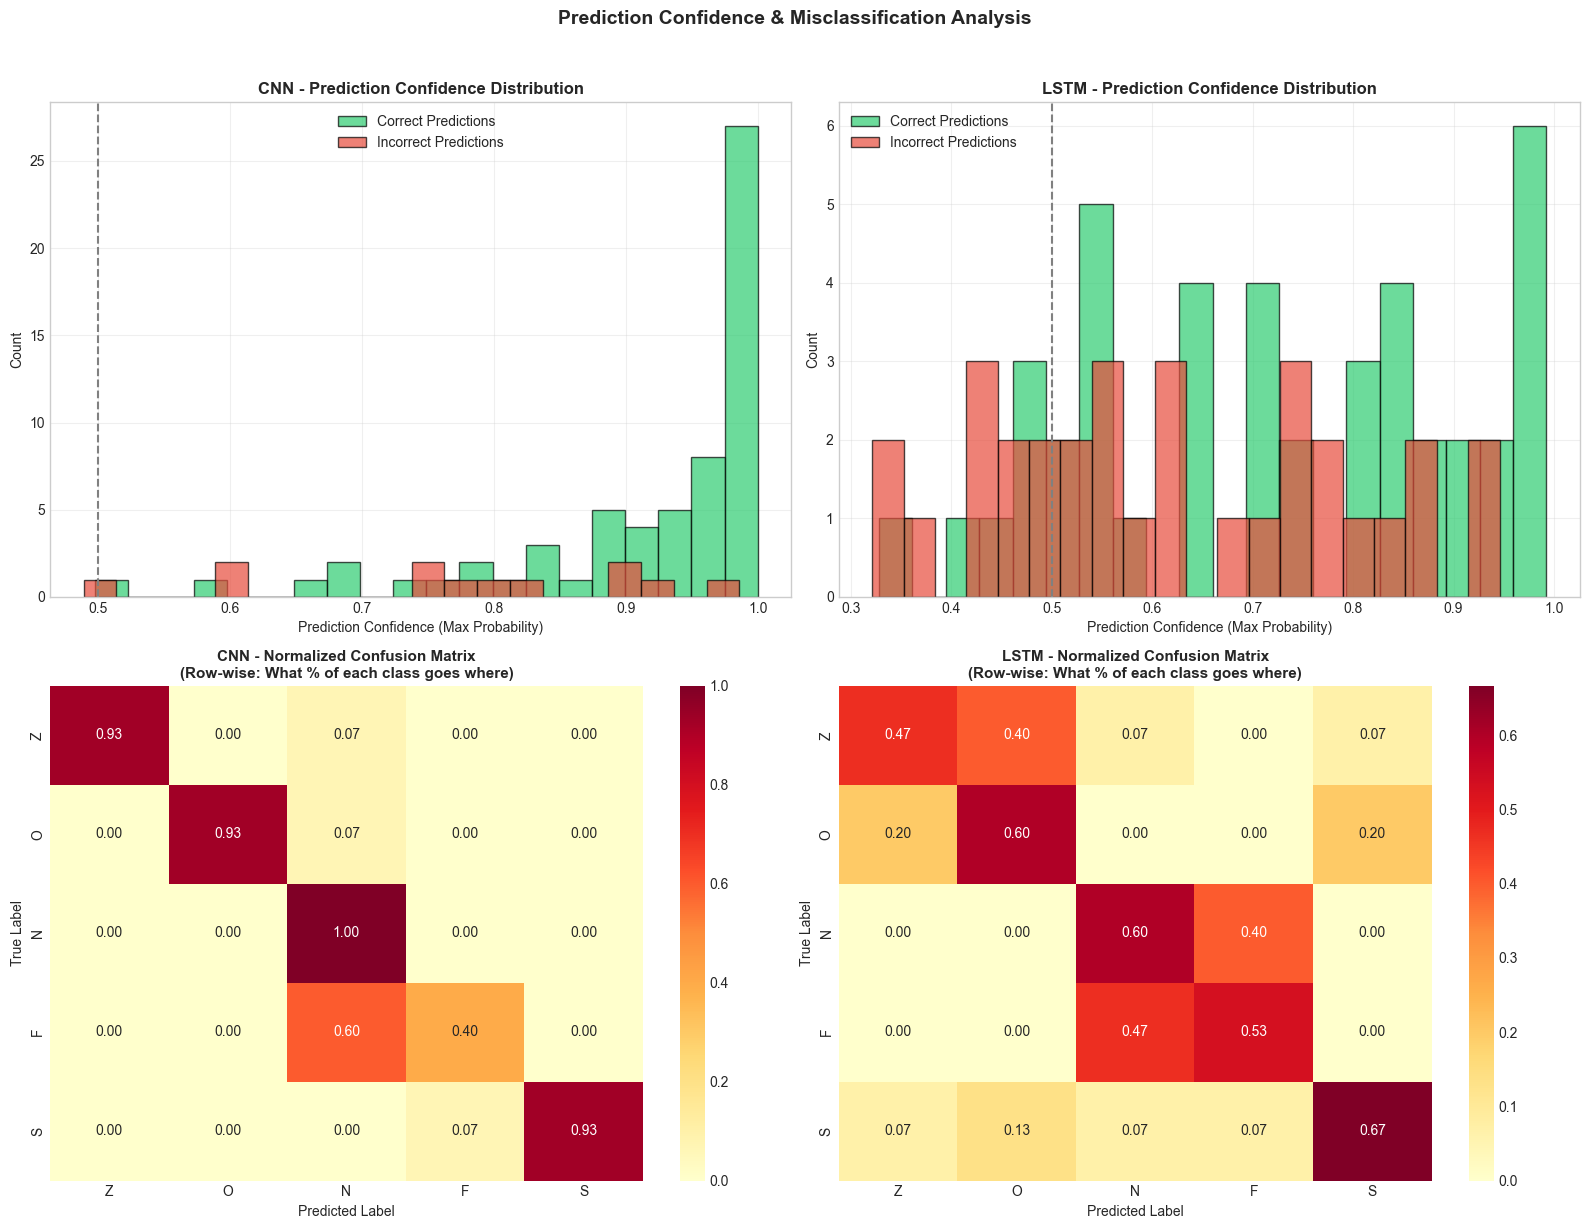


=== Prediction Confidence Statistics ===

CNN:
   Mean confidence (correct): 0.9168
   Mean confidence (incorrect): 0.7757
   Predictions with >90% confidence: 47/75

LSTM:
   Mean confidence (correct): 0.7210
   Mean confidence (incorrect): 0.6173
   Predictions with >90% confidence: 12/75


In [61]:
# Prediction Confidence Analysis and Misclassification Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get prediction probabilities for validation set
cnn_probs_val = cnn_model.predict(X_cnn_val, verbose=0)
lstm_probs_val = lstm_model.predict(X_lstm_val, verbose=0)

# 1. CNN Prediction Confidence Distribution
ax1 = axes[0, 0]
cnn_max_probs = np.max(cnn_probs_val, axis=1)
cnn_correct = y_raw_val == y_pred_cnn_classes
ax1.hist(cnn_max_probs[cnn_correct], bins=20, alpha=0.7, label='Correct Predictions', color='#2ecc71', edgecolor='black')
ax1.hist(cnn_max_probs[~cnn_correct], bins=20, alpha=0.7, label='Incorrect Predictions', color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Prediction Confidence (Max Probability)')
ax1.set_ylabel('Count')
ax1.set_title('CNN - Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(x=0.5, color='gray', linestyle='--', label='50% threshold')

# 2. LSTM Prediction Confidence Distribution
ax2 = axes[0, 1]
lstm_max_probs = np.max(lstm_probs_val, axis=1)
lstm_correct = y_raw_val == y_pred_lstm_classes
ax2.hist(lstm_max_probs[lstm_correct], bins=20, alpha=0.7, label='Correct Predictions', color='#2ecc71', edgecolor='black')
ax2.hist(lstm_max_probs[~lstm_correct], bins=20, alpha=0.7, label='Incorrect Predictions', color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Prediction Confidence (Max Probability)')
ax2.set_ylabel('Count')
ax2.set_title('LSTM - Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axvline(x=0.5, color='gray', linestyle='--', label='50% threshold')

# 3. Misclassification Matrix for CNN (which class gets confused with which)
ax3 = axes[1, 0]
cm_cnn = cnn_results['confusion_matrix']
# Normalize confusion matrix by row (true labels)
cm_cnn_normalized = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_cnn_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Z', 'O', 'N', 'F', 'S'], 
            yticklabels=['Z', 'O', 'N', 'F', 'S'], ax=ax3)
ax3.set_title('CNN - Normalized Confusion Matrix\n(Row-wise: What % of each class goes where)', fontsize=11, fontweight='bold')
ax3.set_ylabel('True Label')
ax3.set_xlabel('Predicted Label')

# 4. Misclassification Matrix for LSTM
ax4 = axes[1, 1]
cm_lstm = lstm_results['confusion_matrix']
cm_lstm_normalized = cm_lstm.astype('float') / cm_lstm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_lstm_normalized, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Z', 'O', 'N', 'F', 'S'], 
            yticklabels=['Z', 'O', 'N', 'F', 'S'], ax=ax4)
ax4.set_title('LSTM - Normalized Confusion Matrix\n(Row-wise: What % of each class goes where)', fontsize=11, fontweight='bold')
ax4.set_ylabel('True Label')
ax4.set_xlabel('Predicted Label')

plt.suptitle('Prediction Confidence & Misclassification Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print confidence statistics
print("\n=== Prediction Confidence Statistics ===")
print(f"\nCNN:")
print(f"   Mean confidence (correct): {cnn_max_probs[cnn_correct].mean():.4f}")
print(f"   Mean confidence (incorrect): {cnn_max_probs[~cnn_correct].mean():.4f}" if sum(~cnn_correct) > 0 else "   No incorrect predictions!")
print(f"   Predictions with >90% confidence: {sum(cnn_max_probs > 0.9)}/{len(cnn_max_probs)}")

print(f"\nLSTM:")
print(f"   Mean confidence (correct): {lstm_max_probs[lstm_correct].mean():.4f}")
print(f"   Mean confidence (incorrect): {lstm_max_probs[~lstm_correct].mean():.4f}" if sum(~lstm_correct) > 0 else "   No incorrect predictions!")
print(f"   Predictions with >90% confidence: {sum(lstm_max_probs > 0.9)}/{len(lstm_max_probs)}")


---
## 9. Testing - Final Evaluation


In [62]:
# Final Testing on Held-Out Test Set
print("\n" + "="*60)
print("FINAL TESTING ON HELD-OUT TEST SET")
print("="*60)
print("\nEvaluating Deep Learning models on unseen test data...")



FINAL TESTING ON HELD-OUT TEST SET

Evaluating Deep Learning models on unseen test data...



--- CNN Test Results ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Evaluation Results: CNN (Test)

Overall Metrics:
  Accuracy:  0.9467
  Precision: 0.9542
  Recall:    0.9467
  F1-Score:  0.9462

Classification Report:
                precision    recall  f1-score   support

    Z (Normal)       1.00      0.93      0.97        15
    O (Normal)       0.94      1.00      0.97        15
N (Interictal)       0.83      1.00      0.91        15
F (Interictal)       1.00      0.80      0.89        15
   S (Seizure)       1.00      1.00      1.00        15

      accuracy                           0.95        75
     macro avg       0.95      0.95      0.95        75
  weighted avg       0.95      0.95      0.95        75



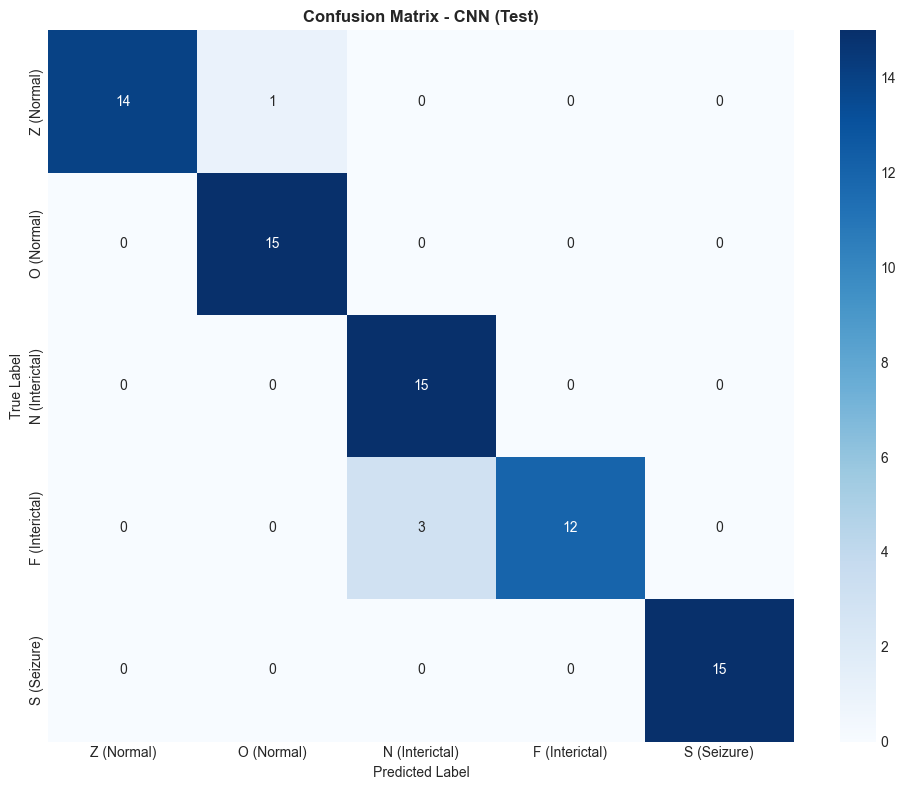

In [63]:
# Test CNN
print("\n--- CNN Test Results ---")
y_pred_cnn_test = cnn_model.predict(X_cnn_test)
y_pred_cnn_test_classes = np.argmax(y_pred_cnn_test, axis=1)
cnn_test_results = evaluate_model(y_raw_test, y_pred_cnn_test_classes, 'CNN (Test)', class_names_list)
plot_confusion_matrix(cnn_test_results['confusion_matrix'], class_names_list, 
                      'CNN (Test)')



--- LSTM Test Results ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

Evaluation Results: LSTM (Test)

Overall Metrics:
  Accuracy:  0.5200
  Precision: 0.5299
  Recall:    0.5200
  F1-Score:  0.5153

Classification Report:
                precision    recall  f1-score   support

    Z (Normal)       0.41      0.47      0.44        15
    O (Normal)       0.62      0.67      0.65        15
N (Interictal)       0.64      0.47      0.54        15
F (Interictal)       0.48      0.67      0.56        15
   S (Seizure)       0.50      0.33      0.40        15

      accuracy                           0.52        75
     macro avg       0.53      0.52      0.52        75
  weighted avg       0.53      0.52      0.52        75



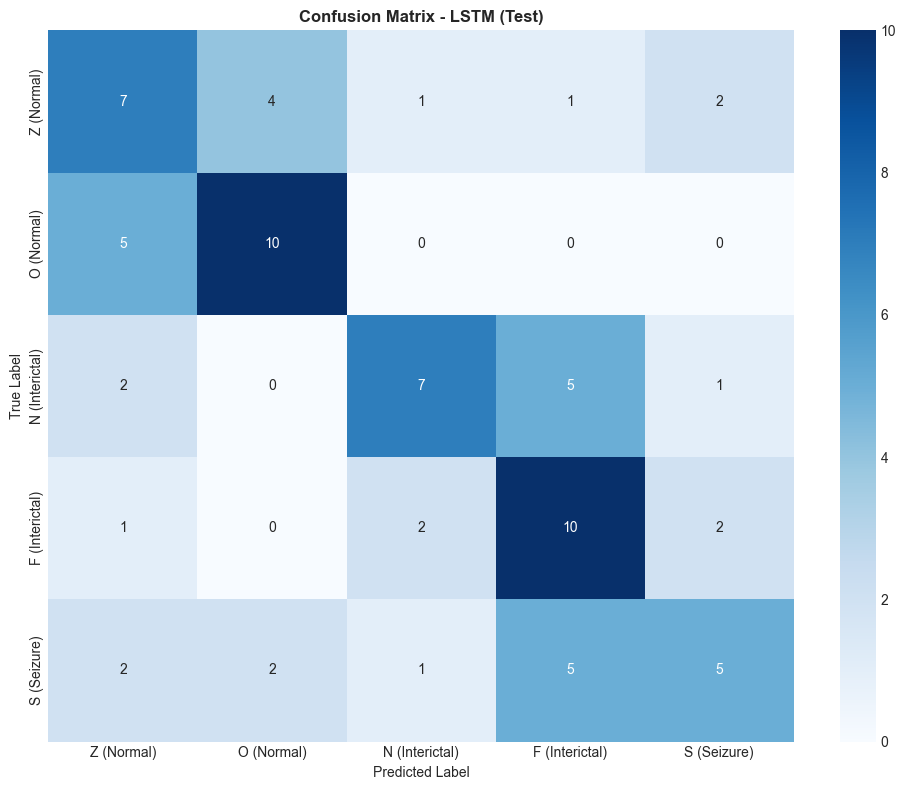

In [64]:
# Test LSTM
print("\n--- LSTM Test Results ---")
y_pred_lstm_test = lstm_model.predict(X_lstm_test)
y_pred_lstm_test_classes = np.argmax(y_pred_lstm_test, axis=1)
lstm_test_results = evaluate_model(y_raw_test, y_pred_lstm_test_classes, 'LSTM (Test)', class_names_list)
plot_confusion_matrix(lstm_test_results['confusion_matrix'], class_names_list, 
                      'LSTM (Test)')


In [65]:
# Final comparison on test set (Deep Learning Models Only)
final_comparison = pd.DataFrame({
    'Model': ['CNN', 'LSTM'],
    'Test Accuracy': [cnn_test_results['accuracy'], lstm_test_results['accuracy']],
    'Test F1-Score': [cnn_test_results['f1'], lstm_test_results['f1']],
    'Test Precision': [cnn_test_results['precision'], lstm_test_results['precision']],
    'Test Recall': [cnn_test_results['recall'], lstm_test_results['recall']]
})

print("\n=== Final Deep Learning Model Test Results ===")
print(final_comparison.to_string(index=False))

# Identify best model
best_model_idx = final_comparison['Test F1-Score'].idxmax()
best_model_name = final_comparison.loc[best_model_idx, 'Model']
best_f1 = final_comparison.loc[best_model_idx, 'Test F1-Score']
best_acc = final_comparison.loc[best_model_idx, 'Test Accuracy']
print(f"\n🏆 Best Deep Learning Model: {best_model_name}")
print(f"   Test Accuracy: {best_acc:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")



=== Final Deep Learning Model Test Results ===
Model  Test Accuracy  Test F1-Score  Test Precision  Test Recall
  CNN       0.946667       0.946248        0.954167     0.946667
 LSTM       0.520000       0.515336        0.529864     0.520000

🏆 Best Deep Learning Model: CNN
   Test Accuracy: 0.9467
   Test F1-Score: 0.9462


---
## 10. Results Visualization and Summary


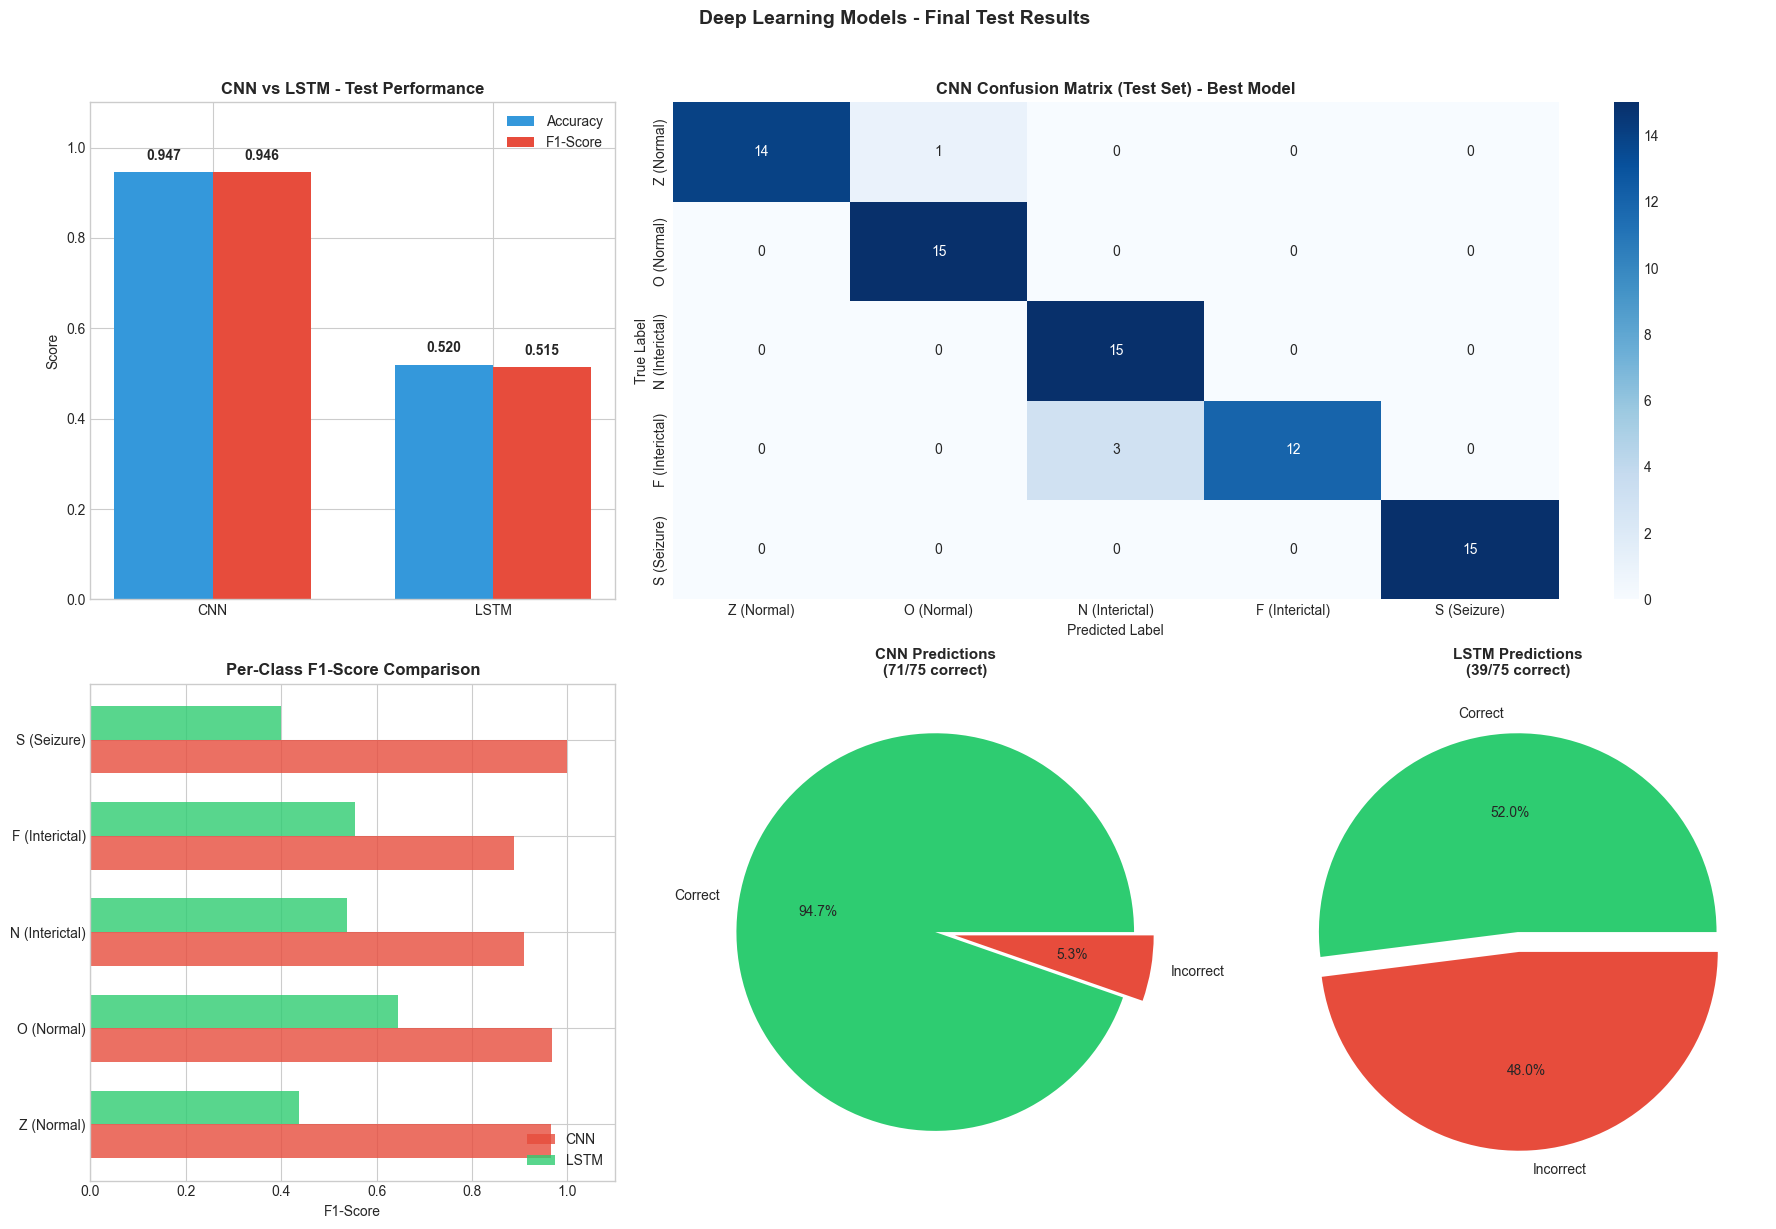

In [66]:
# Create comprehensive results visualization for Deep Learning Models
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, figure=fig)

# Plot 1: Test metrics comparison (CNN vs LSTM)
ax1 = fig.add_subplot(gs[0, 0])
models = ['CNN', 'LSTM']
x = np.arange(len(models))
width = 0.35

acc_bars = ax1.bar(x - width/2, [cnn_test_results['accuracy'], lstm_test_results['accuracy']], 
                   width, label='Accuracy', color='#3498db')
f1_bars = ax1.bar(x + width/2, [cnn_test_results['f1'], lstm_test_results['f1']], 
                  width, label='F1-Score', color='#e74c3c')

ax1.set_ylabel('Score')
ax1.set_title('CNN vs LSTM - Test Performance', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.set_ylim([0, 1.1])

# Add value labels
for bar in acc_bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in f1_bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Confusion matrix for CNN (best model)
ax2 = fig.add_subplot(gs[0, 1:])
sns.heatmap(cnn_test_results['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list, ax=ax2)
ax2.set_title('CNN Confusion Matrix (Test Set) - Best Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# Plot 3: Per-class F1 scores comparison
ax3 = fig.add_subplot(gs[1, 0])
cnn_f1_per_class = f1_score(y_raw_test, y_pred_cnn_test_classes, average=None)
lstm_f1_per_class = f1_score(y_raw_test, y_pred_lstm_test_classes, average=None)

y_pos = np.arange(len(class_names_list))
width = 0.35

ax3.barh(y_pos - width/2, cnn_f1_per_class, width, label='CNN', color='#e74c3c', alpha=0.8)
ax3.barh(y_pos + width/2, lstm_f1_per_class, width, label='LSTM', color='#2ecc71', alpha=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(class_names_list)
ax3.set_xlabel('F1-Score')
ax3.set_title('Per-Class F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 1.1])
ax3.legend(loc='lower right')

# Plot 4: Prediction accuracy pie charts for both models
ax4 = fig.add_subplot(gs[1, 1])
cnn_correct = np.sum(y_raw_test == y_pred_cnn_test_classes)
cnn_incorrect = len(y_raw_test) - cnn_correct
ax4.pie([cnn_correct, cnn_incorrect], labels=['Correct', 'Incorrect'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
ax4.set_title(f'CNN Predictions\n({cnn_correct}/{len(y_raw_test)} correct)', fontsize=11, fontweight='bold')

ax5 = fig.add_subplot(gs[1, 2])
lstm_correct = np.sum(y_raw_test == y_pred_lstm_test_classes)
lstm_incorrect = len(y_raw_test) - lstm_correct
ax5.pie([lstm_correct, lstm_incorrect], labels=['Correct', 'Incorrect'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], explode=[0, 0.1])
ax5.set_title(f'LSTM Predictions\n({lstm_correct}/{len(y_raw_test)} correct)', fontsize=11, fontweight='bold')

plt.suptitle('Deep Learning Models - Final Test Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 11. Conclusion and Summary


In [67]:
# Print comprehensive summary
print("="*70)
print("           EEG CLASSIFICATION PROJECT - FINAL SUMMARY")
print("="*70)

print("\n📊 DATASET SUMMARY:")
print(f"   • Total samples: {len(raw_data)}")
print(f"   • Classes: 5 (Z, O, N, F, S)")
print(f"   • Signal length: {raw_data.shape[1]} samples")
print(f"   • Sampling frequency: {SAMPLING_FREQ} Hz")
print(f"   • Duration per recording: {DURATION} seconds")

print("\n🔧 PREPROCESSING:")
print("   • Bandpass filter: 0.5-50 Hz")
print("   • Z-score normalization")

print("\n📈 FEATURES EXTRACTED:")
print(f"   • Time-domain features: 12")
print(f"   • Frequency-domain features: 14")
print(f"   • Hjorth parameters: 3")
print(f"   • RQA features: 7")
print(f"   • Recurrence Network features: 4")
print(f"   • Total features: {len(feature_cols)}")

print("\n🔄 DATA AUGMENTATION:")
print(f"   • Techniques: Jittering, Scaling, Time Shift, Permutation, Magnitude Warp")
print(f"   • Augmentation factor: {AUGMENTATION_FACTOR}x")
print(f"   • Original training samples: {len(X_raw_train)}")
print(f"   • Augmented training samples: {len(X_raw_train_aug)}")

print("\n🤖 DEEP LEARNING MODELS TRAINED:")
print("   • 1D Convolutional Neural Network (CNN)")
print("     - 4 Conv blocks with BatchNorm and Dropout")
print("     - L2 regularization")
print("     - Global Average Pooling")
print("   • Bidirectional LSTM")
print("     - 3 BiLSTM layers with recurrent dropout")
print("     - L2 regularization")
print("     - Dense layers with BatchNorm")

print("\n📊 FINAL TEST RESULTS:")
print(f"   {'Model':<20} {'Accuracy':<12} {'F1-Score':<12}")
print(f"   {'-'*44}")
print(f"   {'CNN':<20} {cnn_test_results['accuracy']:<12.4f} {cnn_test_results['f1']:<12.4f}")
print(f"   {'LSTM':<20} {lstm_test_results['accuracy']:<12.4f} {lstm_test_results['f1']:<12.4f}")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {final_comparison.loc[best_model_idx, 'Test Accuracy']:.4f}")
print(f"   Test F1-Score: {best_f1:.4f}")




           EEG CLASSIFICATION PROJECT - FINAL SUMMARY

📊 DATASET SUMMARY:
   • Total samples: 500
   • Classes: 5 (Z, O, N, F, S)
   • Signal length: 4097 samples
   • Sampling frequency: 173.61 Hz
   • Duration per recording: 23.6 seconds

🔧 PREPROCESSING:
   • Bandpass filter: 0.5-50 Hz
   • Z-score normalization

📈 FEATURES EXTRACTED:
   • Time-domain features: 12
   • Frequency-domain features: 14
   • Hjorth parameters: 3
   • RQA features: 7
   • Recurrence Network features: 4
   • Total features: 40

🔄 DATA AUGMENTATION:
   • Techniques: Jittering, Scaling, Time Shift, Permutation, Magnitude Warp
   • Augmentation factor: 3x
   • Original training samples: 350
   • Augmented training samples: 1400

🤖 DEEP LEARNING MODELS TRAINED:
   • 1D Convolutional Neural Network (CNN)
     - 4 Conv blocks with BatchNorm and Dropout
     - L2 regularization
     - Global Average Pooling
   • Bidirectional LSTM
     - 3 BiLSTM layers with recurrent dropout
     - L2 regularization
     - Dense